# Multivariate Matrix Profile Analysis: BTC & ETH (2025)

## 1. Introduction and Objectives
This notebook implements a thesis-ready **multivariate motif and discord analysis** for BTCUSDT and ETHUSDT on 2025 market data using `stumpy.mstump`.

### Why start with month-test mode?
Multivariate STOMP on CPU scales poorly with long 1-minute series, so the notebook defaults to a **one-month validation pass** before any full-year production run. This keeps the workflow honest: inspect the feature set, verify the extraction logic, and validate the plots on a tractable slice before paying the full runtime cost.

### Methodological commitments in this notebook
- **Common feature space**: BTC and ETH must use the exact same ordered feature list, otherwise cross-asset motif comparison is not well defined.
- **Full-dimensional ranking**: motif and discord ranking uses the last row of `mstump`, which corresponds to the full-dimensional profile across all selected channels.
- **Event-table intersection logic**: each motif contributes both a query window and a match window, and BTC-vs-ETH alignment is evaluated across the full event tables rather than query timestamps alone.
- **True multivariate validation**: anchor-event inspection uses feature panels, z-normalized motif-window overlays, and per-feature diagnostics instead of relying on price plots only.


## 2. Configuration and Imports

The notebook exposes explicit execution controls near the top. `RUN_MODE = "month_test"` is the default because it is the correct first-pass validation mode for CPU-based multivariate `mstump`; the full-year path remains available for final production runs.


In [1]:
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stumpy
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore")

RUN_MODE = "month_test"   # options: "month_test", "full_year"
TEST_MONTH = "2025-06"
YEAR_START = "2025-01-01"
YEAR_END = "2025-12-31 23:59:59"
USE_5MIN = False
WINDOW = 60
TOP_K = 15
TOLERANCE_HOURS_LIST = [1, 6, 12, 24]

BAR_MINUTES = 5 if USE_5MIN else 1
if WINDOW % BAR_MINUTES != 0:
    raise ValueError(f"WINDOW={WINDOW} minutes is not divisible by BAR_MINUTES={BAR_MINUTES}.")
WINDOW_BARS = WINDOW // BAR_MINUTES
PROFILE_WARN_THRESHOLD = 20_000 if BAR_MINUTES == 1 else 5_000


def resolve_project_root() -> Path:
    search_roots = [Path.cwd(), *Path.cwd().parents]
    for base in search_roots:
        data_dir = base / "data" / "processed" / "crypto" / "1min"
        if data_dir.exists():
            return base
        nested_data_dir = base / "MastersThesis" / "data" / "processed" / "crypto" / "1min"
        if nested_data_dir.exists():
            return base / "MastersThesis"
    raise FileNotFoundError("Could not locate project root containing data/processed/crypto/1min")


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "crypto" / "1min"

print(f"Project root: {PROJECT_ROOT}")
print(f"Selected run mode: {RUN_MODE}")
print(f"Base bar frequency: {BAR_MINUTES}-minute")
print(f"Motif window: {WINDOW} minutes ({WINDOW_BARS} bars)")
print(f"Top-K motifs/discords: {TOP_K}")
print(f"Tolerance sweep (hours): {TOLERANCE_HOURS_LIST}")


Project root: c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis
Selected run mode: month_test
Base bar frequency: 1-minute
Motif window: 60 minutes (60 bars)
Top-K motifs/discords: 15
Tolerance sweep (hours): [1, 6, 12, 24]


## 3. Data Loading and Robust Filtering

This section makes the execution mode explicit. The notebook prints the selected period and the row counts before and after filtering so that month-test and full-year runs are easy to verify from the output alone.


In [2]:
def resolve_period_bounds():
    if RUN_MODE == "month_test":
        period_start = pd.Timestamp(f"{TEST_MONTH}-01 00:00:00", tz="UTC")
        period_end = period_start + pd.DateOffset(months=1) - pd.Timedelta(seconds=1)
        period_label = f"{TEST_MONTH} (UTC month slice)"
    elif RUN_MODE == "full_year":
        period_start = pd.Timestamp(YEAR_START, tz="UTC")
        period_end = pd.Timestamp(YEAR_END, tz="UTC")
        period_label = "2025 full calendar year (UTC)"
    else:
        raise ValueError(f"Unsupported RUN_MODE: {RUN_MODE}")
    return period_start, period_end, period_label


PERIOD_START, PERIOD_END, PERIOD_LABEL = resolve_period_bounds()
print(f"Selected period: {PERIOD_START} -> {PERIOD_END}")


def load_raw_asset_data(asset_symbol: str) -> pd.DataFrame:
    candidate_paths = [
        DATA_DIR / f"{asset_symbol}_1m_processed.parquet",
        DATA_DIR / f"{asset_symbol}_1m_features.parquet",
    ]
    asset_path = next((path for path in candidate_paths if path.exists()), None)
    if asset_path is None:
        raise FileNotFoundError(f"No parquet file found for {asset_symbol} in {DATA_DIR}")

    df = pd.read_parquet(asset_path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.sort_values("timestamp").reset_index(drop=True)
    print(f"{asset_symbol}: loaded {len(df):,} rows from {asset_path.name}")
    return df


def resample_ohlcv(df: pd.DataFrame, bar_minutes: int) -> pd.DataFrame:
    if bar_minutes == 1:
        return df.copy()

    ohlcv_cols = ["open", "high", "low", "close", "volume"]
    missing_cols = [col for col in ohlcv_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Cannot resample without OHLCV columns: {missing_cols}")

    rule = f"{bar_minutes}min"
    resampled = (
        df.set_index("timestamp")
          .resample(rule, label="left", closed="left")
          .agg(
              {
                  "open": "first",
                  "high": "max",
                  "low": "min",
                  "close": "last",
                  "volume": "sum",
              }
          )
          .dropna()
          .reset_index()
    )
    return resampled


def engineer_canonical_features(df: pd.DataFrame, bar_minutes: int) -> pd.DataFrame:
    out = df.copy()
    periods_per_hour = max(1, 60 // bar_minutes)
    periods_per_day = max(periods_per_hour * 24, periods_per_hour)

    close = out["close"].astype(float)
    open_ = out["open"].astype(float)
    high = out["high"].astype(float)
    low = out["low"].astype(float)
    volume = out["volume"].astype(float)

    if bar_minutes == 1 and "log_return" in out.columns:
        out["log_return"] = out["log_return"].astype(float)
    else:
        out["log_return"] = np.log(close).diff()

    if bar_minutes == 1 and "pct_return" in out.columns:
        out["pct_return"] = out["pct_return"].astype(float)
    else:
        out["pct_return"] = close.pct_change()

    out["hl_range"] = (high - low) / close.replace(0, np.nan)
    out["oc_change"] = (close - open_) / open_.replace(0, np.nan)

    if bar_minutes == 1 and "volatility_60m" in out.columns:
        out["volatility_60m"] = out["volatility_60m"].astype(float)
    else:
        out["volatility_60m"] = out["log_return"].rolling(periods_per_hour, min_periods=periods_per_hour).std()

    if bar_minutes == 1 and "realized_volatility_60m" in out.columns:
        out["rv_60"] = out["realized_volatility_60m"].astype(float)
    elif bar_minutes == 1 and "rv_60" in out.columns:
        out["rv_60"] = out["rv_60"].astype(float)
    else:
        out["rv_60"] = np.sqrt(
            out["log_return"].pow(2).rolling(periods_per_hour, min_periods=periods_per_hour).sum()
        )

    volume_roll = volume.rolling(periods_per_day, min_periods=periods_per_hour)
    out["volume_zscore"] = (
        (volume - volume_roll.mean()) / volume_roll.std(ddof=0).replace(0, np.nan)
    )
    out["log_volume"] = np.log1p(volume.clip(lower=0))
    out["volume_change"] = volume.pct_change().replace([np.inf, -np.inf], np.nan)

    return out.replace([np.inf, -np.inf], np.nan)


def prepare_asset_frame(asset_symbol: str) -> pd.DataFrame:
    raw_df = load_raw_asset_data(asset_symbol)
    rows_before_filter = len(raw_df)
    filtered_df = raw_df.loc[
        (raw_df["timestamp"] >= PERIOD_START) & (raw_df["timestamp"] <= PERIOD_END)
    ].copy()
    rows_after_filter = len(filtered_df)

    print(
        f"{asset_symbol}: rows before filter = {rows_before_filter:,}, "
        f"after filter = {rows_after_filter:,}"
    )
    if filtered_df.empty:
        raise ValueError(f"{asset_symbol}: no rows available inside the selected period {PERIOD_LABEL}")

    if USE_5MIN:
        filtered_df = resample_ohlcv(filtered_df, BAR_MINUTES)
        print(f"{asset_symbol}: rows after {BAR_MINUTES}-minute resample = {len(filtered_df):,}")

    feature_df = engineer_canonical_features(filtered_df, BAR_MINUTES)
    print(
        f"{asset_symbol}: final time span = {feature_df['timestamp'].min()} -> "
        f"{feature_df['timestamp'].max()}"
    )
    return feature_df.reset_index(drop=True)


df_btc = prepare_asset_frame("BTCUSDT")
df_eth = prepare_asset_frame("ETHUSDT")


Selected period: 2025-06-01 00:00:00+00:00 -> 2025-06-30 23:59:59+00:00
BTCUSDT: loaded 4,502,648 rows from BTCUSDT_1m_processed.parquet
BTCUSDT: rows before filter = 4,502,648, after filter = 43,200
BTCUSDT: final time span = 2025-06-01 00:00:00+00:00 -> 2025-06-30 23:59:00+00:00
ETHUSDT: loaded 4,504,088 rows from ETHUSDT_1m_processed.parquet
ETHUSDT: rows before filter = 4,504,088, after filter = 43,200
ETHUSDT: final time span = 2025-06-01 00:00:00+00:00 -> 2025-06-30 23:59:00+00:00


## 4. Common Feature Selection

Cross-asset multivariate comparison requires a **shared ordered feature list**. Selecting BTC and ETH channels independently would let each asset optimize against a different representation, which breaks the interpretation of any BTC-vs-ETH motif alignment.

The resolver below first inspects the candidate engineered features available for each asset, then constructs the ordered common set, and finally applies a small amount of redundancy control so that obviously synonymous channels do not overweight one market dimension.


In [ ]:
FEATURE_PRIORITY = [
    "log_return",
    "pct_return",
    "hl_range",
    "oc_change",
    "volatility_60m",
    "volatility_60",
    "rv_60",
    "volume_zscore",
    "log_volume",
    "volume_change",
]

FEATURE_GROUPS = [
    ("returns", ["log_return", "pct_return"]),
    ("range", ["hl_range"]),
    ("open_close_change", ["oc_change"]),
    ("rolling_volatility", ["volatility_60m", "volatility_60"]),
    ("realized_volatility", ["rv_60"]),
    ("volume_state", ["volume_zscore", "log_volume", "volume_change"]),
]

ALIAS_NOTES = {
    "volatility_60": "volatility_60m",
    "realized_volatility_60m": "rv_60",
}


def inspect_candidate_features(df: pd.DataFrame, candidate_features, min_non_null: int) -> list[str]:
    available = []
    for feature_name in candidate_features:
        if feature_name not in df.columns:
            continue
        non_null_count = int(df[feature_name].notna().sum())
        if non_null_count >= min_non_null:
            available.append(feature_name)
    return available


def resolve_common_feature_set(
    btc_df: pd.DataFrame,
    eth_df: pd.DataFrame,
    candidate_features,
    feature_groups,
    min_non_null: int,
):
    btc_available = inspect_candidate_features(btc_df, candidate_features, min_non_null=min_non_null)
    eth_available = inspect_candidate_features(eth_df, candidate_features, min_non_null=min_non_null)
    common_candidates = [feature for feature in candidate_features if feature in btc_available and feature in eth_available]

    selected = []
    resolution_notes = []
    common_set = set(common_candidates)

    for group_name, options in feature_groups:
        group_hits = [option for option in options if option in common_set]
        if not group_hits:
            continue
        chosen = group_hits[0]
        selected.append(chosen)
        if len(group_hits) > 1:
            resolution_notes.append(
                f"{group_name}: chose {chosen} and skipped {group_hits[1:]} to avoid redundant channels"
            )

    return btc_available, eth_available, common_candidates, selected, resolution_notes


min_non_null_required = max(WINDOW_BARS * 4, 100)
(
    btc_available_features,
    eth_available_features,
    common_candidate_features,
    ,
    feature_resolution_notes,
) = resolve_common_feature_set(
    df_btc,
    df_eth,
    FEATURE_PRIORITY,
    FEATURE_GROUPS,
    min_non_null=min_non_null_required,
)

print("BTC available candidate features:", btc_available_features)
print("ETH available candidate features:", eth_available_features)
print("Common candidate features:", common_candidate_features)
print("Final selected common features used for both assets:", selected_features)
print("Alias resolution notes:", ALIAS_NOTES)
if feature_resolution_notes:
    print("Selection notes:")
    for note in feature_resolution_notes:
        print(f"- {note}")

if len(selected_features) < 3:
    warnings.warn(
        "Fewer than 3 common meaningful features remain after resolution. "
        "Proceed with caution; multivariate motifs may be weakly identified."
    )
if len(selected_features) < 2:
    raise ValueError(
        "Need at least 2 useful common features to proceed with multivariate motif discovery."
    )

feature_availability_df = pd.DataFrame(
    {
        "feature": selected_features,
        "btc_non_null": [int(df_btc[feature].notna().sum()) for feature in selected_features],
        "eth_non_null": [int(df_eth[feature].notna().sum()) for feature in selected_features],
    }
)
display(feature_availability_df)


BTC available candidate features: ['log_return', 'pct_return', 'hl_range', 'oc_change', 'volatility_60m', 'rv_60', 'volume_zscore', 'log_volume', 'volume_change']
ETH available candidate features: ['log_return', 'pct_return', 'hl_range', 'oc_change', 'volatility_60m', 'rv_60', 'volume_zscore', 'log_volume', 'volume_change']
Common candidate features: ['log_return', 'pct_return', 'hl_range', 'oc_change', 'volatility_60m', 'rv_60', 'volume_zscore', 'log_volume', 'volume_change']
Final selected common features used for both assets: ['log_return', 'hl_range', 'oc_change', 'volatility_60m', 'rv_60', 'volume_zscore']
Alias resolution notes: {'volatility_60': 'volatility_60m', 'realized_volatility_60m': 'rv_60'}
Selection notes:
- returns: chose log_return and skipped ['pct_return'] to avoid redundant channels
- volume_state: chose volume_zscore and skipped ['log_volume', 'volume_change'] to avoid redundant channels


,feature,btc_non_null,eth_non_null
0,log_return,43200,43200
1,hl_range,43200,43200
2,oc_change,43200,43200
3,volatility_60m,43200,43200
4,rv_60,43200,43200
5,volume_zscore,43141,43141


## 5. Multivariate Preprocessing

The selected feature channels are globally standardized on the current slice before being passed to `mstump`. This global scaling keeps the channels on a comparable magnitude scale, but it does **not** replace the subsequence-level z-normalization used inside matrix profile distance calculations. In other words:

- **Global scaling** keeps one feature family, such as volume, from dominating purely because of its raw variance.
- **Subsequence normalization inside `mstump`** is what makes local shape comparison robust when the same feature appears at different levels.


In [4]:
def global_standardize(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    mean_value = np.nanmean(values)
    std_value = np.nanstd(values)
    if not np.isfinite(std_value) or std_value == 0:
        return np.zeros_like(values, dtype=np.float64)
    return (values - mean_value) / std_value


def prepare_mstump_input(df: pd.DataFrame, features: list[str], asset_name: str):
    keep_columns = ["timestamp", "open", "high", "low", "close", "volume", *features]
    keep_columns = list(dict.fromkeys([column for column in keep_columns if column in df.columns]))
    rows_before_drop = len(df)

    df_clean = (
        df[keep_columns]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=features)
        .reset_index(drop=True)
        .copy()
    )
    rows_after_drop = len(df_clean)

    if rows_after_drop <= WINDOW_BARS:
        raise ValueError(
            f"{asset_name}: need more than {WINDOW_BARS} clean rows after feature alignment, got {rows_after_drop}."
        )

    matrix = np.vstack(
        [
            global_standardize(df_clean[feature].to_numpy(dtype=np.float64))
            for feature in features
        ]
    )

    print(
        f"{asset_name}: rows before NaN drop = {rows_before_drop:,}, "
        f"after = {rows_after_drop:,}, dropped = {rows_before_drop - rows_after_drop:,}"
    )
    print(f"{asset_name}: mstump input matrix shape = {matrix.shape}")
    return df_clean, matrix


df_btc_clean, btc_matrix = prepare_mstump_input(df_btc, selected_features, asset_name="BTCUSDT")
df_eth_clean, eth_matrix = prepare_mstump_input(df_eth, selected_features, asset_name="ETHUSDT")


BTCUSDT: rows before NaN drop = 43,200, after = 43,141, dropped = 59
BTCUSDT: mstump input matrix shape = (6, 43141)
ETHUSDT: rows before NaN drop = 43,200, after = 43,141, dropped = 59
ETHUSDT: mstump input matrix shape = (6, 43141)


## 6. Multivariate Matrix Profile Computation (`mstump`)

### What do the `mstump` rows mean?
For `d` selected features, `mstump` returns profile and index arrays of shape `(d, n - m + 1)`. Row `k` is the best `(k + 1)`-dimensional profile, meaning it captures the subsequence match distance after choosing the best-performing subset of `k + 1` dimensions.

### Why rank on the final row?
This notebook ranks motifs and discords on the **last row** (`d - 1`) because that is the profile where the full common BTC/ETH feature panel is active. Averaging rows would mix different dimensionalities, and pairing that average with one arbitrary index row would be methodologically inconsistent.

### Runtime note
Multivariate `mstump` remains CPU-heavy, especially on long 1-minute slices. Month-test mode is therefore the default audit path; full-year runs should only be attempted after the feature set and plots look correct on the smaller slice.


In [5]:
def warn_if_large_input(matrix: np.ndarray, asset_name: str):
    series_length = matrix.shape[1]
    subsequence_count = series_length - WINDOW_BARS + 1
    if series_length >= PROFILE_WARN_THRESHOLD:
        warnings.warn(
            f"{asset_name}: {series_length:,} clean rows ({subsequence_count:,} subsequences) at "
            f"{BAR_MINUTES}-minute bars. CPU mstump may take a long time. "
            f"If this is an exploratory run, consider USE_5MIN=True or a shorter month slice first."
        )


n_dim = len(selected_features)
full_dim_row = n_dim - 1
print(f"Using full-dimensional mstump row index: {full_dim_row} (d={n_dim})")

warn_if_large_input(btc_matrix, asset_name="BTCUSDT")
warn_if_large_input(eth_matrix, asset_name="ETHUSDT")

print(f"Computing BTC mstump with m={WINDOW_BARS} bars ({WINDOW} minutes) across {n_dim} features...")
btc_start_time = perf_counter()
p_btc, i_btc = stumpy.mstump(btc_matrix, m=WINDOW_BARS)
btc_runtime_seconds = perf_counter() - btc_start_time
print(f"BTC mstump complete in {btc_runtime_seconds:.2f}s | output shape: {p_btc.shape}")

print()
print(f"Computing ETH mstump with m={WINDOW_BARS} bars ({WINDOW} minutes) across {n_dim} features...")
eth_start_time = perf_counter()
p_eth, i_eth = stumpy.mstump(eth_matrix, m=WINDOW_BARS)
eth_runtime_seconds = perf_counter() - eth_start_time
print(f"ETH mstump complete in {eth_runtime_seconds:.2f}s | output shape: {p_eth.shape}")

runtime_summary_df = pd.DataFrame(
    [
        {"asset": "BTC", "runtime_seconds": btc_runtime_seconds, "profile_rows": p_btc.shape[0], "profile_cols": p_btc.shape[1]},
        {"asset": "ETH", "runtime_seconds": eth_runtime_seconds, "profile_rows": p_eth.shape[0], "profile_cols": p_eth.shape[1]},
    ]
)
display(runtime_summary_df)


Using full-dimensional mstump row index: 5 (d=6)
Computing BTC mstump with m=60 bars (60 minutes) across 6 features...
BTC mstump complete in 164.46s | output shape: (6, 43082)

Computing ETH mstump with m=60 bars (60 minutes) across 6 features...
ETH mstump complete in 158.48s | output shape: (6, 43082)


,asset,runtime_seconds,profile_rows,profile_cols
0,BTC,164.459374,6,43082
1,ETH,158.484939,6,43082


## 7. Motif and Discord Extraction

Motif extraction and discord extraction both use the **same full-dimensional profile row**. This keeps the ranking policy consistent: the strongest motifs are the lowest-distance full-panel matches, and the strongest discords are the highest-distance full-panel subsequences.


In [6]:
def get_full_dim_profile(profile_matrix: np.ndarray, index_matrix: np.ndarray, asset_name: str):
    if profile_matrix.shape != index_matrix.shape:
        raise ValueError(f"{asset_name}: profile and index shapes do not match: {profile_matrix.shape} vs {index_matrix.shape}")
    if profile_matrix.ndim != 2:
        raise ValueError(f"{asset_name}: expected 2D mstump outputs, got {profile_matrix.ndim} dimensions")

    selected_row = profile_matrix.shape[0] - 1
    profile = np.asarray(profile_matrix[selected_row], dtype=np.float64)
    indices = np.asarray(index_matrix[selected_row], dtype=np.int64)
    return selected_row, profile, indices


def apply_exclusion(mask: np.ndarray, center_index: int, exclusion_radius: int):
    left = max(0, center_index - exclusion_radius)
    right = min(len(mask), center_index + exclusion_radius + 1)
    mask[left:right] = True


def extract_motifs_and_discords(
    profile_matrix: np.ndarray,
    index_matrix: np.ndarray,
    df_clean: pd.DataFrame,
    m: int,
    top_k: int,
    asset_name: str,
):
    selected_row, full_profile, full_indices = get_full_dim_profile(profile_matrix, index_matrix, asset_name=asset_name)
    exclusion_radius = max(1, m // 2)

    motifs = []
    motif_mask = np.zeros(len(full_profile), dtype=bool)
    for query_index in np.argsort(full_profile):
        if motif_mask[query_index]:
            continue
        if not np.isfinite(full_profile[query_index]):
            continue

        match_index = int(full_indices[query_index])
        if match_index < 0 or match_index >= len(df_clean):
            continue
        if abs(match_index - query_index) <= exclusion_radius:
            continue

        motifs.append(
            {
                "rank": len(motifs) + 1,
                "profile_value": float(full_profile[query_index]),
                "query_index": int(query_index),
                "match_index": int(match_index),
                "query_time": df_clean.loc[query_index, "timestamp"],
                "query_end_time": df_clean.loc[min(query_index + m - 1, len(df_clean) - 1), "timestamp"],
                "match_time": df_clean.loc[match_index, "timestamp"],
                "match_end_time": df_clean.loc[min(match_index + m - 1, len(df_clean) - 1), "timestamp"],
            }
        )

        apply_exclusion(motif_mask, query_index, exclusion_radius)
        apply_exclusion(motif_mask, match_index, exclusion_radius)
        if len(motifs) >= top_k:
            break

    discords = []
    discord_mask = np.zeros(len(full_profile), dtype=bool)
    for discord_index in np.argsort(full_profile)[::-1]:
        if discord_mask[discord_index]:
            continue
        if not np.isfinite(full_profile[discord_index]):
            continue

        discords.append(
            {
                "discord_rank": len(discords) + 1,
                "discord_index": int(discord_index),
                "discord_score": float(full_profile[discord_index]),
                "discord_time": df_clean.loc[discord_index, "timestamp"],
                "discord_end_time": df_clean.loc[min(discord_index + m - 1, len(df_clean) - 1), "timestamp"],
            }
        )

        apply_exclusion(discord_mask, discord_index, exclusion_radius)
        if len(discords) >= top_k:
            break

    motif_df = pd.DataFrame(motifs)
    discord_df = pd.DataFrame(discords)
    return selected_row, full_profile, full_indices, motif_df, discord_df


(
    btc_full_dim_row,
    btc_full_profile,
    btc_full_indices,
    motif_df_btc,
    discord_df_btc,
) = extract_motifs_and_discords(
    p_btc,
    i_btc,
    df_btc_clean,
    m=WINDOW_BARS,
    top_k=TOP_K,
    asset_name="BTCUSDT",
)

(
    eth_full_dim_row,
    eth_full_profile,
    eth_full_indices,
    motif_df_eth,
    discord_df_eth,
) = extract_motifs_and_discords(
    p_eth,
    i_eth,
    df_eth_clean,
    m=WINDOW_BARS,
    top_k=TOP_K,
    asset_name="ETHUSDT",
)

print(f"BTC full-dimensional row used for ranking: {btc_full_dim_row}")
print(f"ETH full-dimensional row used for ranking: {eth_full_dim_row}")

print("BTC motif table (top 5):")
display(motif_df_btc.head(5))
print("BTC discord table (top 5):")
display(discord_df_btc.head(5))
print("ETH motif table (top 5):")
display(motif_df_eth.head(5))
print("ETH discord table (top 5):")
display(discord_df_eth.head(5))


BTC full-dimensional row used for ranking: 5
ETH full-dimensional row used for ranking: 5
BTC motif table (top 5):


,rank,profile_value,query_index,match_index,query_time,query_end_time,match_time,match_end_time
0,1,4.163216,40363,15959,2025-06-29 01:42:00+00:00,2025-06-29 02:41:00+00:00,2025-06-12 02:58:00+00:00,2025-06-12 03:57:00+00:00
1,2,4.362947,39732,7845,2025-06-28 15:11:00+00:00,2025-06-28 16:10:00+00:00,2025-06-06 11:44:00+00:00,2025-06-06 12:43:00+00:00
2,3,4.384693,15068,39755,2025-06-11 12:07:00+00:00,2025-06-11 13:06:00+00:00,2025-06-28 15:34:00+00:00,2025-06-28 16:33:00+00:00
3,4,4.517694,15036,40717,2025-06-11 11:35:00+00:00,2025-06-11 12:34:00+00:00,2025-06-29 07:36:00+00:00,2025-06-29 08:35:00+00:00
4,5,4.576981,6782,43002,2025-06-05 18:01:00+00:00,2025-06-05 19:00:00+00:00,2025-06-30 21:41:00+00:00,2025-06-30 22:40:00+00:00


BTC discord table (top 5):


,discord_rank,discord_index,discord_score,discord_time,discord_end_time
0,1,14259,9.125358,2025-06-10 22:38:00+00:00,2025-06-10 23:37:00+00:00
1,2,25679,9.008654,2025-06-18 20:58:00+00:00,2025-06-18 21:57:00+00:00
2,3,13772,8.998906,2025-06-10 14:31:00+00:00,2025-06-10 15:30:00+00:00
3,4,41059,8.925635,2025-06-29 13:18:00+00:00,2025-06-29 14:17:00+00:00
4,5,34959,8.872266,2025-06-25 07:38:00+00:00,2025-06-25 08:37:00+00:00


ETH motif table (top 5):


,rank,profile_value,query_index,match_index,query_time,query_end_time,match_time,match_end_time
0,1,2.237300,6285,29971,2025-06-05 09:44:00+00:00,2025-06-05 10:43:00+00:00,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00
1,2,2.485316,6799,6280,2025-06-05 18:18:00+00:00,2025-06-05 19:17:00+00:00,2025-06-05 09:39:00+00:00,2025-06-05 10:38:00+00:00
2,3,2.509632,41468,6282,2025-06-29 20:07:00+00:00,2025-06-29 21:06:00+00:00,2025-06-05 09:41:00+00:00,2025-06-05 10:40:00+00:00
3,4,2.606838,10544,41481,2025-06-08 08:43:00+00:00,2025-06-08 09:42:00+00:00,2025-06-29 20:20:00+00:00,2025-06-29 21:19:00+00:00
4,5,2.632476,31337,6286,2025-06-22 19:16:00+00:00,2025-06-22 20:15:00+00:00,2025-06-05 09:45:00+00:00,2025-06-05 10:44:00+00:00


ETH discord table (top 5):


,discord_rank,discord_index,discord_score,discord_time,discord_end_time
0,1,40685,8.819797,2025-06-29 07:04:00+00:00,2025-06-29 08:03:00+00:00
1,2,18948,8.799598,2025-06-14 04:47:00+00:00,2025-06-14 05:46:00+00:00
2,3,37823,8.783841,2025-06-27 07:22:00+00:00,2025-06-27 08:21:00+00:00
3,4,36198,8.757748,2025-06-26 04:17:00+00:00,2025-06-26 05:16:00+00:00
4,5,34331,8.756706,2025-06-24 21:10:00+00:00,2025-06-24 22:09:00+00:00


## 8. Asset-Level Validation Plots

The motif and discord validation plots below are deliberately multivariate. Price remains useful for context, but each figure also exposes the selected feature channels so that recurrence or anomaly claims are supported by the full panel rather than by close alone.


BTC top motif validation


,rank,profile_value,query_index,match_index,query_time,query_end_time,match_time,match_end_time
0,1,4.163216,40363,15959,2025-06-29 01:42:00+00:00,2025-06-29 02:41:00+00:00,2025-06-12 02:58:00+00:00,2025-06-12 03:57:00+00:00


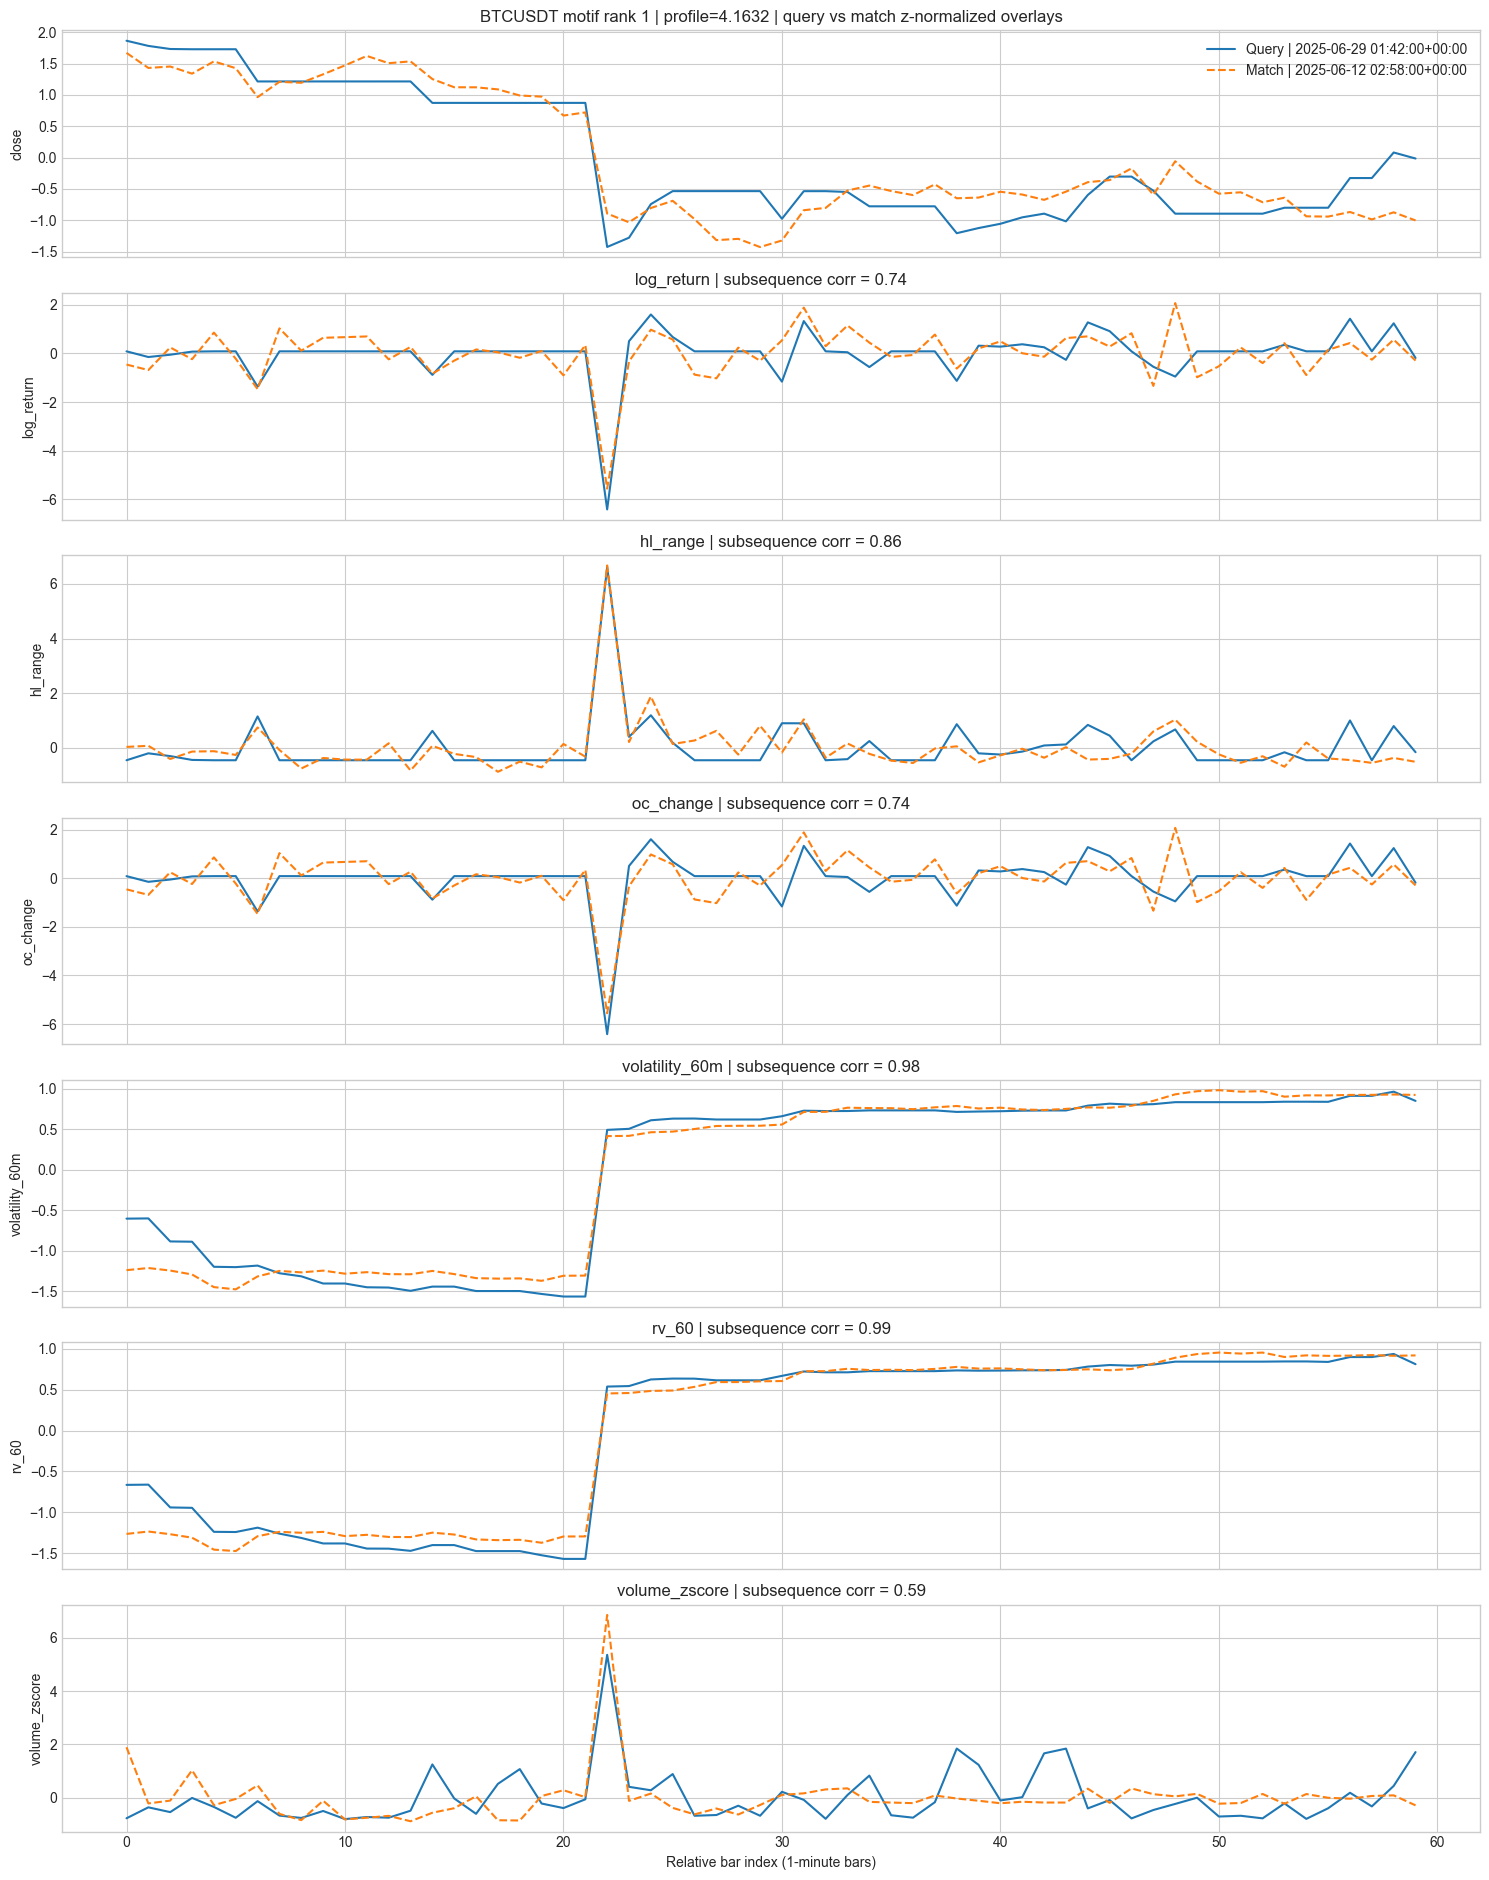

ETH top motif validation


,rank,profile_value,query_index,match_index,query_time,query_end_time,match_time,match_end_time
0,1,2.2373,6285,29971,2025-06-05 09:44:00+00:00,2025-06-05 10:43:00+00:00,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00


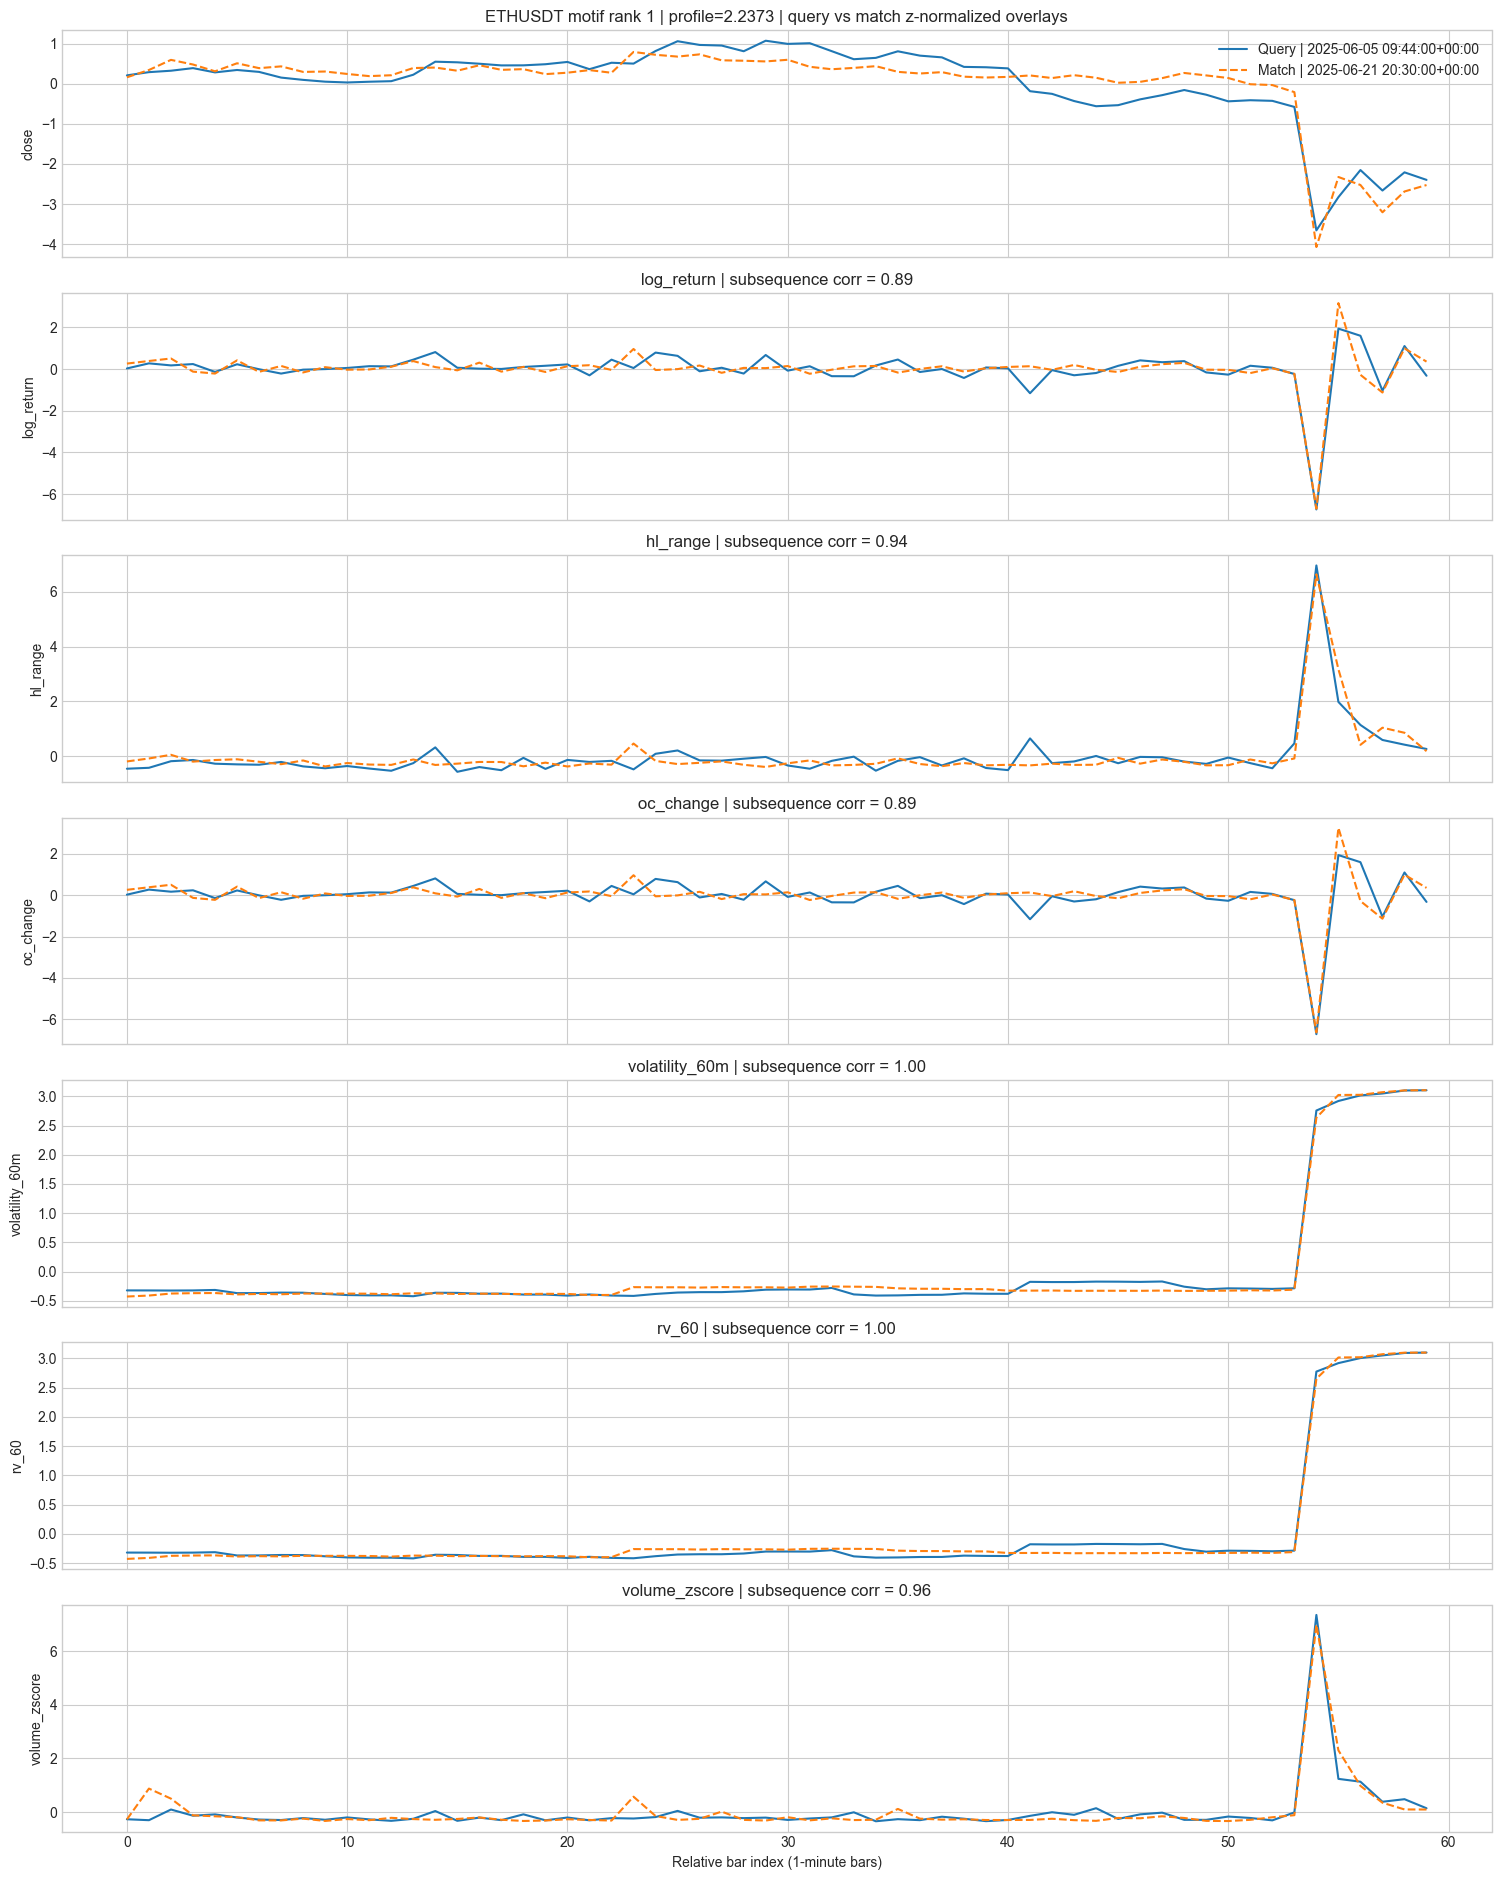

BTC top discord validation


,discord_rank,discord_index,discord_score,discord_time,discord_end_time
0,1,14259,9.125358,2025-06-10 22:38:00+00:00,2025-06-10 23:37:00+00:00


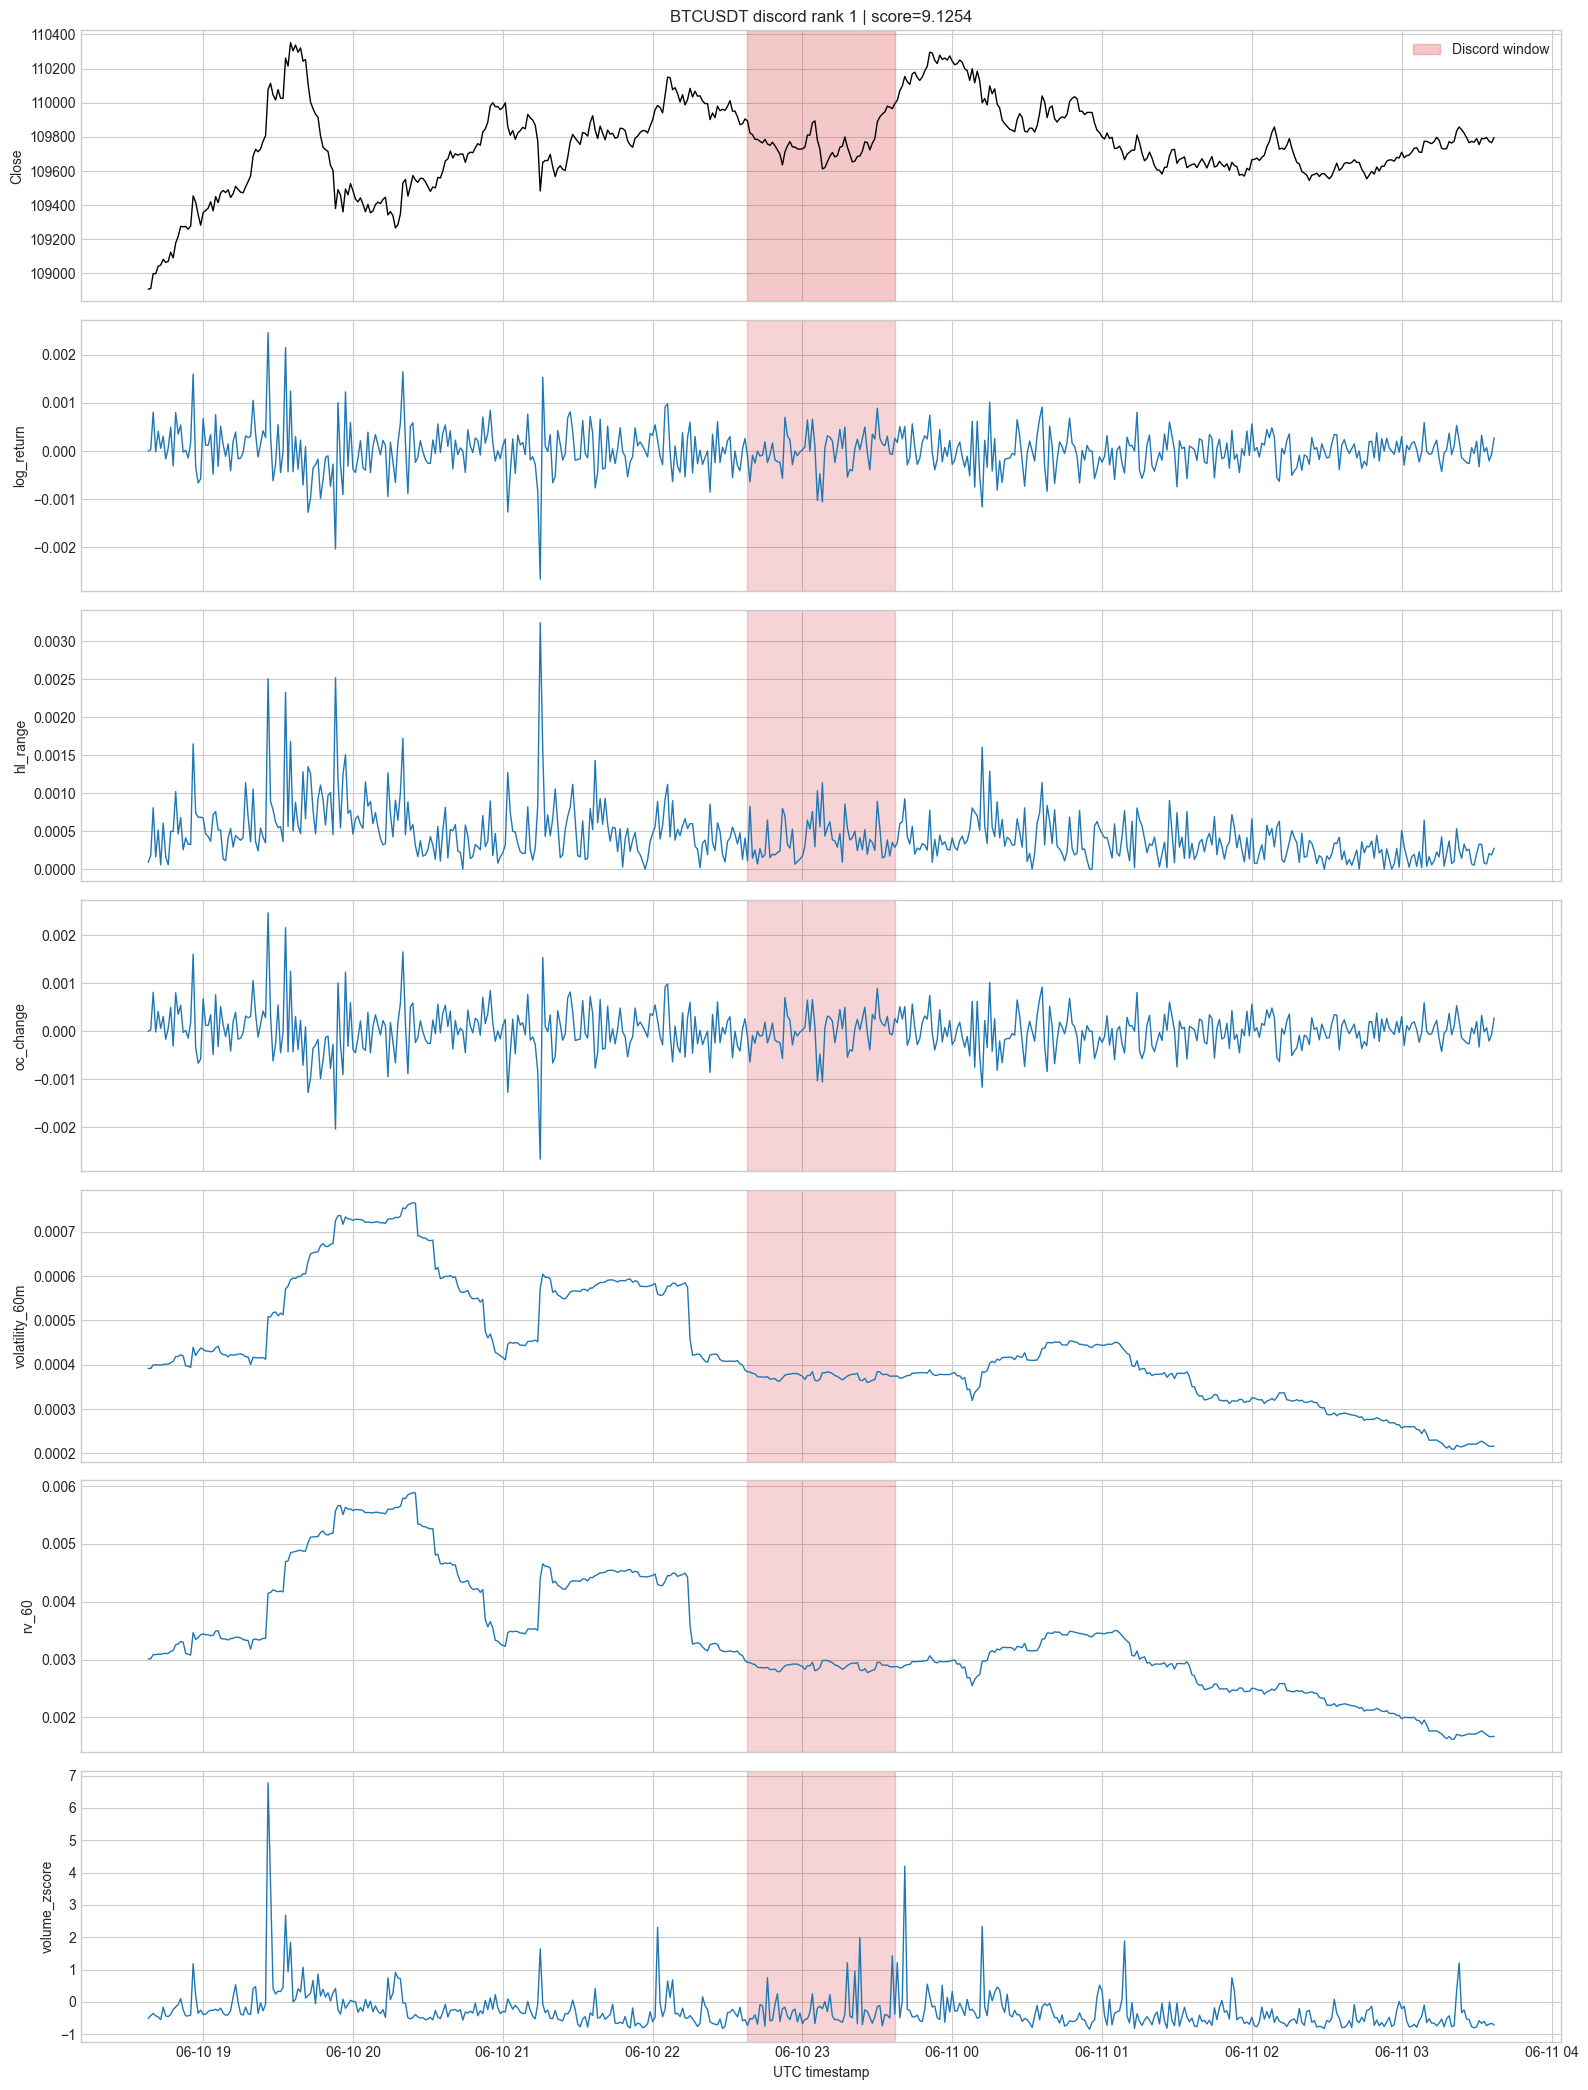

ETH top discord validation


,discord_rank,discord_index,discord_score,discord_time,discord_end_time
0,1,40685,8.819797,2025-06-29 07:04:00+00:00,2025-06-29 08:03:00+00:00


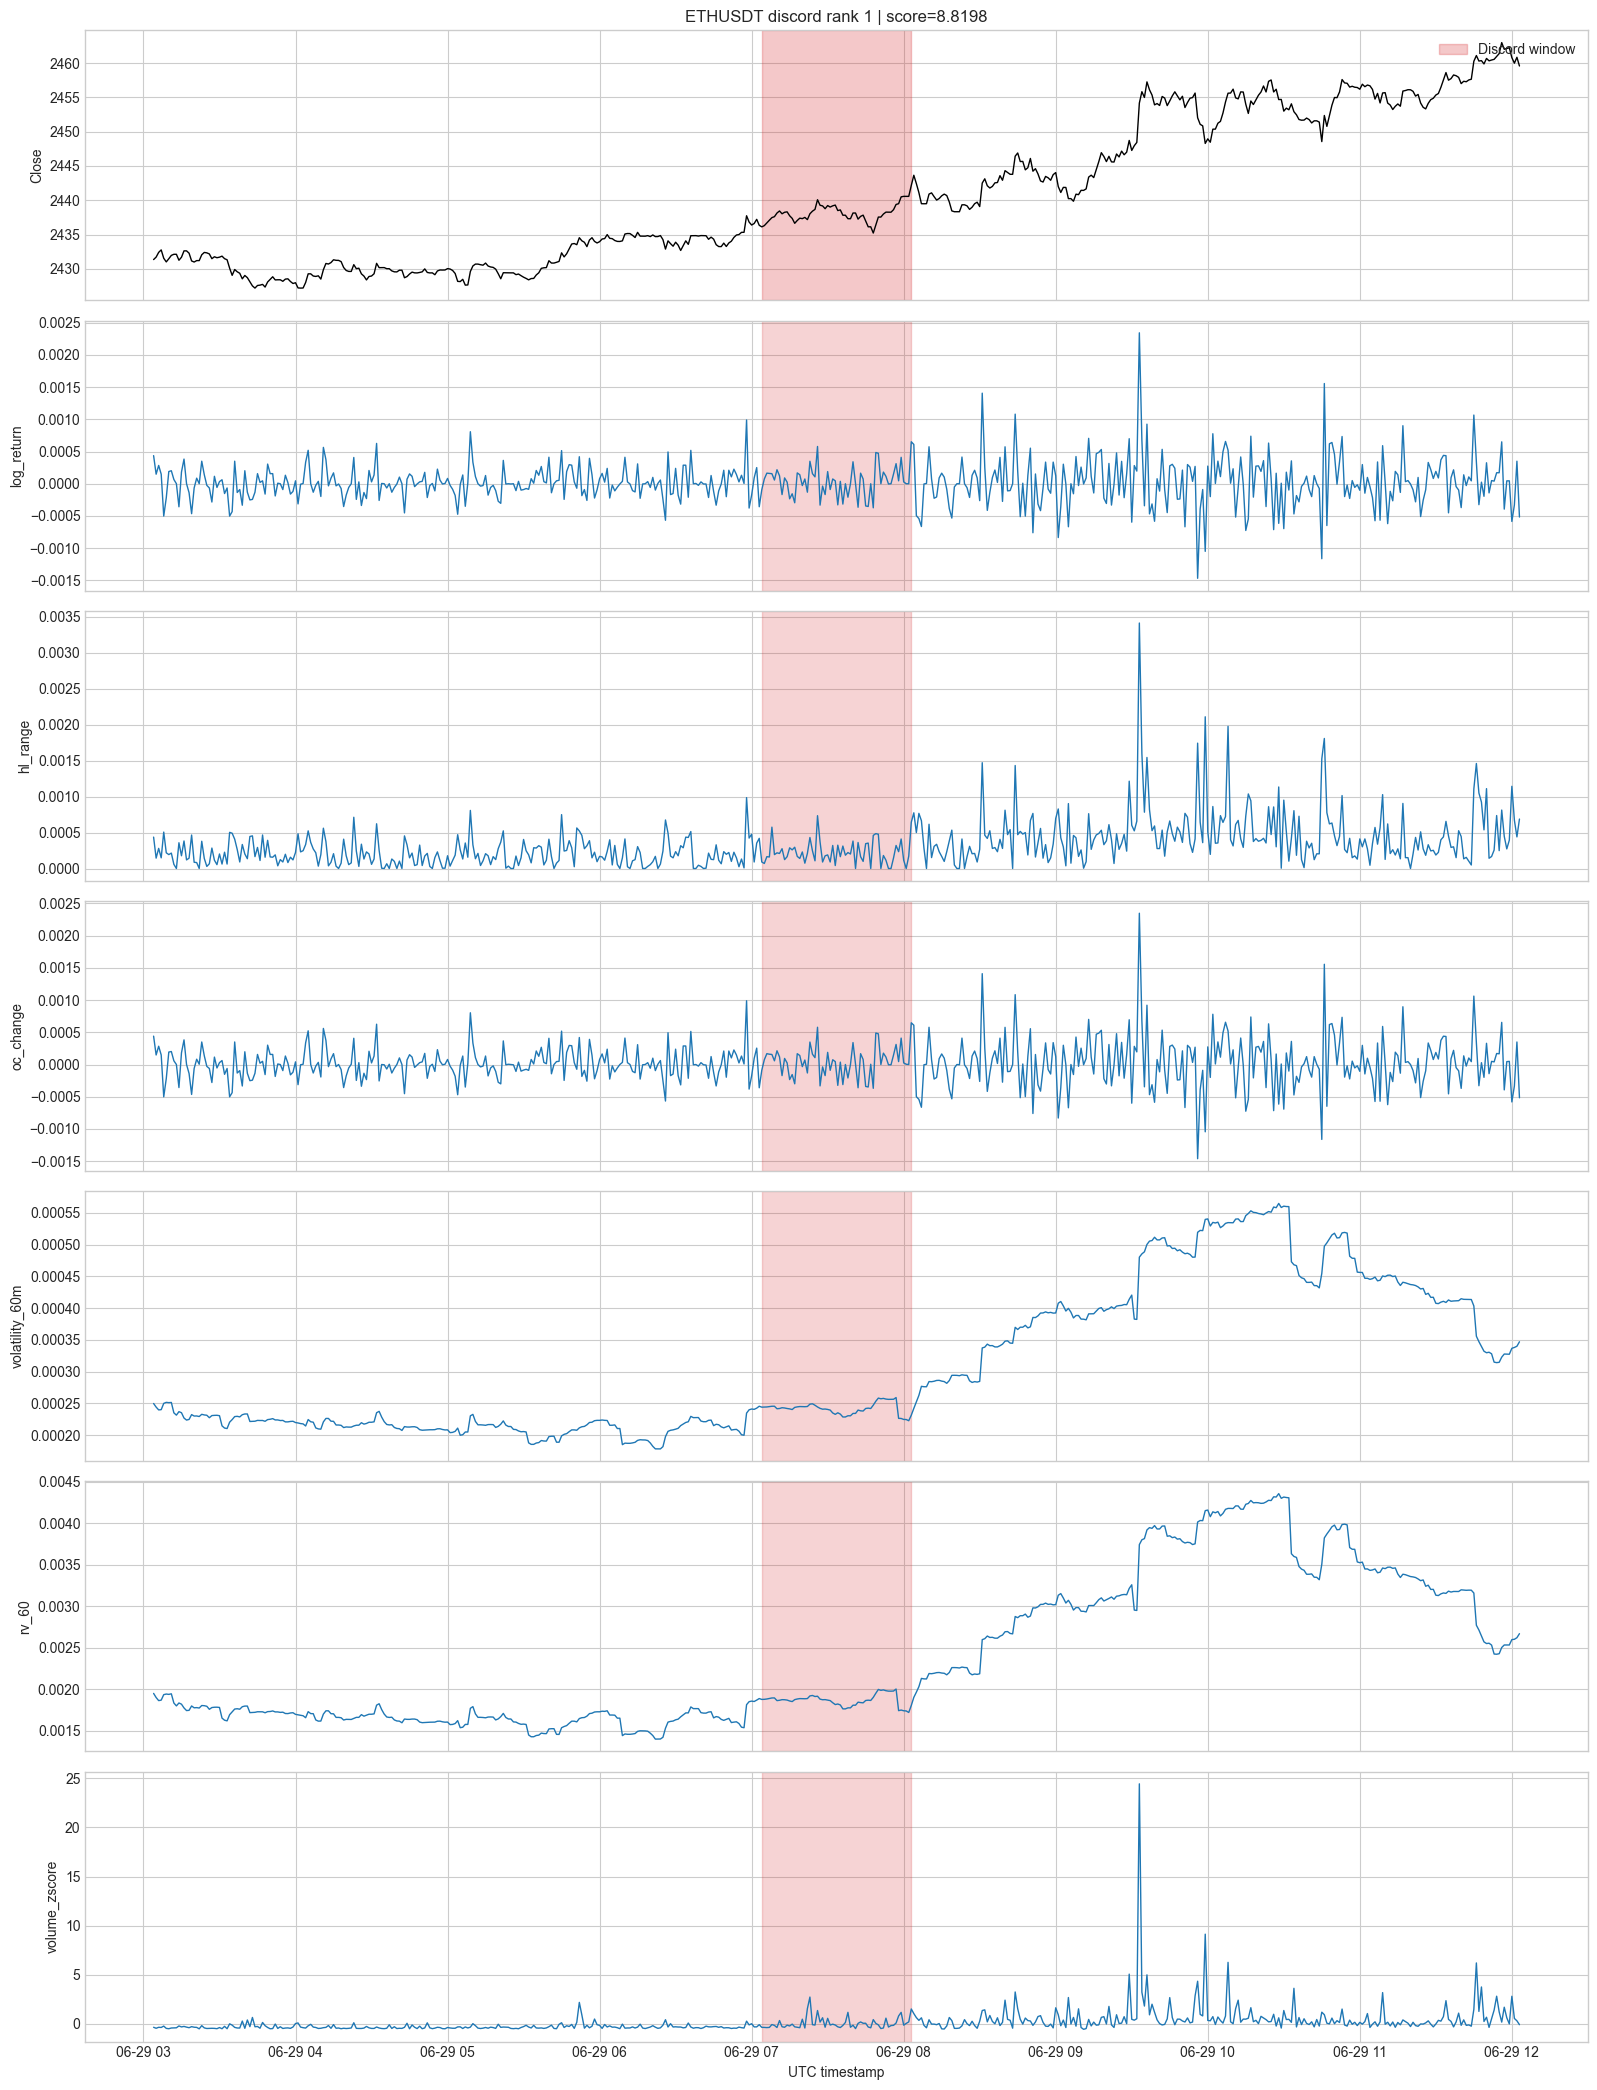

In [7]:
def zscore_subsequence(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    std_value = np.nanstd(values)
    if not np.isfinite(std_value) or std_value == 0:
        return np.zeros_like(values, dtype=np.float64)
    return (values - np.nanmean(values)) / std_value


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) != len(b) or len(a) == 0:
        return float("nan")
    a_std = np.nanstd(a)
    b_std = np.nanstd(b)
    if a_std == 0 or b_std == 0:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


def plot_multivariate_motif_validation(
    df_clean: pd.DataFrame,
    motif_row: pd.Series,
    features: list[str],
    asset_name: str,
    m: int,
):
    query_index = int(motif_row["query_index"])
    match_index = int(motif_row["match_index"])

    fig, axes = plt.subplots(len(features) + 1, 1, figsize=(15, 2.7 * (len(features) + 1)), sharex=True)

    query_close = zscore_subsequence(df_clean["close"].iloc[query_index: query_index + m].to_numpy())
    match_close = zscore_subsequence(df_clean["close"].iloc[match_index: match_index + m].to_numpy())
    axes[0].plot(query_close, label=f"Query | {motif_row['query_time']}", color="tab:blue")
    axes[0].plot(match_close, label=f"Match | {motif_row['match_time']}", color="tab:orange", linestyle="--")
    axes[0].set_ylabel("close")
    axes[0].set_title(
        f"{asset_name} motif rank {int(motif_row['rank'])} | profile={motif_row['profile_value']:.4f} | "
        f"query vs match z-normalized overlays"
    )
    axes[0].legend(loc="upper right")

    for axis, feature_name in zip(axes[1:], features):
        query_values = zscore_subsequence(df_clean[feature_name].iloc[query_index: query_index + m].to_numpy())
        match_values = zscore_subsequence(df_clean[feature_name].iloc[match_index: match_index + m].to_numpy())
        axis.plot(query_values, color="tab:blue")
        axis.plot(match_values, color="tab:orange", linestyle="--")
        axis.set_ylabel(feature_name)
        axis.set_title(f"{feature_name} | subsequence corr = {safe_corr(query_values, match_values):.2f}")

    axes[-1].set_xlabel(f"Relative bar index ({BAR_MINUTES}-minute bars)")
    plt.tight_layout()
    plt.show()


def plot_discord_validation(
    df_clean: pd.DataFrame,
    discord_row: pd.Series,
    features: list[str],
    asset_name: str,
    m: int,
    context_multiplier: int = 4,
):
    discord_index = int(discord_row["discord_index"])
    context_bars = max(m, context_multiplier * m)
    left = max(0, discord_index - context_bars)
    right = min(len(df_clean), discord_index + m + context_bars)
    local_df = df_clean.iloc[left:right].copy()

    fig, axes = plt.subplots(len(features) + 1, 1, figsize=(16, 3 * (len(features) + 1)), sharex=True)

    axes[0].plot(local_df["timestamp"], local_df["close"], color="black", linewidth=1.0)
    axes[0].axvspan(discord_row["discord_time"], discord_row["discord_end_time"], color="tab:red", alpha=0.25, label="Discord window")
    axes[0].set_ylabel("Close")
    axes[0].set_title(
        f"{asset_name} discord rank {int(discord_row['discord_rank'])} | score={discord_row['discord_score']:.4f}"
    )
    axes[0].legend(loc="upper right")

    for axis, feature_name in zip(axes[1:], features):
        axis.plot(local_df["timestamp"], local_df[feature_name], color="tab:blue", linewidth=1.0)
        axis.axvspan(discord_row["discord_time"], discord_row["discord_end_time"], color="tab:red", alpha=0.20)
        axis.set_ylabel(feature_name)

    axes[-1].set_xlabel("UTC timestamp")
    plt.tight_layout()
    plt.show()


if not motif_df_btc.empty:
    print("BTC top motif validation")
    display(pd.DataFrame([motif_df_btc.iloc[0]]))
    plot_multivariate_motif_validation(df_btc_clean, motif_df_btc.iloc[0], selected_features, "BTCUSDT", WINDOW_BARS)

if not motif_df_eth.empty:
    print("ETH top motif validation")
    display(pd.DataFrame([motif_df_eth.iloc[0]]))
    plot_multivariate_motif_validation(df_eth_clean, motif_df_eth.iloc[0], selected_features, "ETHUSDT", WINDOW_BARS)

if not discord_df_btc.empty:
    print("BTC top discord validation")
    display(pd.DataFrame([discord_df_btc.iloc[0]]))
    plot_discord_validation(df_btc_clean, discord_df_btc.iloc[0], selected_features, "BTCUSDT", WINDOW_BARS)

if not discord_df_eth.empty:
    print("ETH top discord validation")
    display(pd.DataFrame([discord_df_eth.iloc[0]]))
    plot_discord_validation(df_eth_clean, discord_df_eth.iloc[0], selected_features, "ETHUSDT", WINDOW_BARS)


## 9. Cross-Asset Motif Intersection Analysis

This section upgrades the notebook from query-time matching to a full **event-table** analysis. Each motif generates two windows, `query` and `match`, and the intersection logic compares **all BTC motif windows against all ETH motif windows**.

The tolerance sweep mirrors the stronger univariate workflow by running the comparison at ?1 hour, ?6 hours, ?12 hours, and ?24 hours. Each intersecting pair is classified as:
- **Very strong**: 0 to 3 minutes
- **Strong**: over 3 minutes up to 60 minutes
- **Moderate**: over 60 minutes up to 180 minutes
- **Weak**: over 180 minutes but still inside the active tolerance


In [8]:
ALIGNMENT_ORDER = ["Very strong", "Strong", "Moderate", "Weak"]


def classify_alignment_strength(delta_minutes: float) -> str:
    if delta_minutes <= 3:
        return "Very strong"
    if delta_minutes <= 60:
        return "Strong"
    if delta_minutes <= 180:
        return "Moderate"
    return "Weak"


def build_motif_event_table(motif_df: pd.DataFrame, asset_name: str) -> pd.DataFrame:
    rows = []
    for _, row in motif_df.iterrows():
        rows.append(
            {
                "asset": asset_name,
                "motif_rank": int(row["rank"]),
                "window_type": "query",
                "start_time": pd.to_datetime(row["query_time"], utc=True),
                "end_time": pd.to_datetime(row["query_end_time"], utc=True),
                "profile_value": float(row["profile_value"]),
            }
        )
        rows.append(
            {
                "asset": asset_name,
                "motif_rank": int(row["rank"]),
                "window_type": "match",
                "start_time": pd.to_datetime(row["match_time"], utc=True),
                "end_time": pd.to_datetime(row["match_end_time"], utc=True),
                "profile_value": float(row["profile_value"]),
            }
        )
    return pd.DataFrame(rows).sort_values(["start_time", "motif_rank", "window_type"]).reset_index(drop=True)


def compare_event_tables(
    btc_events: pd.DataFrame,
    eth_events: pd.DataFrame,
    tolerance_hours: int,
) -> pd.DataFrame:
    tolerance_minutes = tolerance_hours * 60
    intersections = []

    for _, btc_row in btc_events.iterrows():
        for _, eth_row in eth_events.iterrows():
            signed_delta_minutes = (
                btc_row["start_time"] - eth_row["start_time"]
            ).total_seconds() / 60.0
            abs_delta_minutes = abs(signed_delta_minutes)
            if abs_delta_minutes > tolerance_minutes:
                continue

            intersections.append(
                {
                    "btc_motif_rank": int(btc_row["motif_rank"]),
                    "btc_window_type": btc_row["window_type"],
                    "btc_start_time": btc_row["start_time"],
                    "btc_end_time": btc_row["end_time"],
                    "btc_profile_value": float(btc_row["profile_value"]),
                    "eth_motif_rank": int(eth_row["motif_rank"]),
                    "eth_window_type": eth_row["window_type"],
                    "eth_start_time": eth_row["start_time"],
                    "eth_end_time": eth_row["end_time"],
                    "eth_profile_value": float(eth_row["profile_value"]),
                    "signed_delta_minutes": signed_delta_minutes,
                    "time_delta_minutes": abs_delta_minutes,
                }
            )

    intersection_df = pd.DataFrame(intersections)
    if intersection_df.empty:
        return intersection_df

    intersection_df["alignment_strength"] = intersection_df["time_delta_minutes"].apply(classify_alignment_strength)
    intersection_df["anchor_time"] = intersection_df[["btc_start_time", "eth_start_time"]].min(axis=1)
    intersection_df["anchor_date"] = intersection_df["anchor_time"].dt.date.astype(str)
    intersection_df["combined_profile_value"] = (
        intersection_df["btc_profile_value"] + intersection_df["eth_profile_value"]
    )

    return intersection_df.sort_values(
        ["time_delta_minutes", "combined_profile_value", "btc_motif_rank", "eth_motif_rank"]
    ).reset_index(drop=True)


def build_date_summary(intersection_df: pd.DataFrame) -> pd.DataFrame:
    if intersection_df.empty:
        return pd.DataFrame()
    date_summary = (
        intersection_df.groupby("anchor_date")
        .agg(
            total_intersections=("anchor_date", "size"),
            closest_gap_minutes=("time_delta_minutes", "min"),
            median_gap_minutes=("time_delta_minutes", "median"),
            unique_btc_motifs=("btc_motif_rank", "nunique"),
            unique_eth_motifs=("eth_motif_rank", "nunique"),
        )
        .reset_index()
        .sort_values(["closest_gap_minutes", "total_intersections"], ascending=[True, False])
    )
    date_summary["date_strength"] = date_summary["closest_gap_minutes"].apply(classify_alignment_strength)
    return date_summary


def build_strength_summary(intersection_df: pd.DataFrame) -> pd.DataFrame:
    if intersection_df.empty:
        return pd.DataFrame()
    strength_summary = (
        intersection_df.groupby("alignment_strength")
        .agg(
            count=("alignment_strength", "size"),
            min_gap_minutes=("time_delta_minutes", "min"),
            median_gap_minutes=("time_delta_minutes", "median"),
            max_gap_minutes=("time_delta_minutes", "max"),
        )
        .reset_index()
    )
    strength_summary["alignment_strength"] = pd.Categorical(
        strength_summary["alignment_strength"],
        categories=ALIGNMENT_ORDER,
        ordered=True,
    )
    return strength_summary.sort_values("alignment_strength")


btc_event_df = build_motif_event_table(motif_df_btc, asset_name="BTC")
eth_event_df = build_motif_event_table(motif_df_eth, asset_name="ETH")

print(f"Total BTC motif windows considered: {len(btc_event_df)}")
print(f"Total ETH motif windows considered: {len(eth_event_df)}")

intersection_results_by_tolerance = {}
overview_rows = []
required_intersection_cols = [
    "btc_motif_rank",
    "btc_window_type",
    "btc_start_time",
    "btc_end_time",
    "eth_motif_rank",
    "eth_window_type",
    "eth_start_time",
    "eth_end_time",
    "time_delta_minutes",
    "alignment_strength",
]

for tolerance_hours in TOLERANCE_HOURS_LIST:
    print("=" * 120)
    print(f"BTC vs ETH multivariate motif intersections | tolerance = +/- {tolerance_hours} hour(s)")
    print("=" * 120)

    tolerance_intersections = compare_event_tables(btc_event_df, eth_event_df, tolerance_hours=tolerance_hours)
    date_summary_df = build_date_summary(tolerance_intersections)
    strength_summary_df = build_strength_summary(tolerance_intersections)

    total_intersections = int(len(tolerance_intersections))
    unique_btc = int(tolerance_intersections["btc_motif_rank"].nunique()) if total_intersections else 0
    unique_eth = int(tolerance_intersections["eth_motif_rank"].nunique()) if total_intersections else 0

    overview_rows.append(
        {
            "tolerance_hours": tolerance_hours,
            "btc_windows": len(btc_event_df),
            "eth_windows": len(eth_event_df),
            "total_intersecting_pairs": total_intersections,
            "unique_btc_motifs": unique_btc,
            "unique_eth_motifs": unique_eth,
        }
    )

    intersection_results_by_tolerance[tolerance_hours] = {
        "intersections": tolerance_intersections,
        "date_summary": date_summary_df,
        "strength_summary": strength_summary_df,
    }

    if tolerance_intersections.empty:
        print("No BTC/ETH motif-event intersections found under this tolerance.")
        continue

    print(f"Total intersecting pairs: {total_intersections}")
    print(f"Unique BTC motifs participating: {unique_btc} / {motif_df_btc['rank'].nunique()}")
    print(f"Unique ETH motifs participating: {unique_eth} / {motif_df_eth['rank'].nunique()}")
    print("Closest intersections")
    display(tolerance_intersections[required_intersection_cols].head(10))
    print("Date-level summary")
    display(date_summary_df)
    print("Strength summary")
    display(strength_summary_df)

intersection_tolerance_overview_df = pd.DataFrame(overview_rows)
print("=" * 120)
print("Tolerance sweep overview")
print("=" * 120)
display(intersection_tolerance_overview_df)

anchor_tolerance_hours = next(
    (
        tolerance_hours
        for tolerance_hours in TOLERANCE_HOURS_LIST
        if not intersection_results_by_tolerance[tolerance_hours]["intersections"].empty
    ),
    None,
)

if anchor_tolerance_hours is None:
    anchor_event_row = None
    anchor_intersections_df = pd.DataFrame()
    print("No common BTC/ETH motif events were found inside the configured tolerance sweep.")
else:
    anchor_intersections_df = intersection_results_by_tolerance[anchor_tolerance_hours]["intersections"]
    anchor_event_row = anchor_intersections_df.iloc[0].copy()
    print(
        f"Anchor event selected from the tightest non-empty tolerance: +/- {anchor_tolerance_hours} hour(s)"
    )
    display(pd.DataFrame([anchor_event_row[required_intersection_cols + ["signed_delta_minutes"]]]))


Total BTC motif windows considered: 30
Total ETH motif windows considered: 30
BTC vs ETH multivariate motif intersections | tolerance = +/- 1 hour(s)
Total intersecting pairs: 10
Unique BTC motifs participating: 6 / 15
Unique ETH motifs participating: 8 / 15
Closest intersections


,btc_motif_rank,btc_window_type,btc_start_time,btc_end_time,eth_motif_rank,eth_window_type,eth_start_time,eth_end_time,time_delta_minutes,alignment_strength
0,12,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,1,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,0.0,Very strong
1,7,match,2025-06-21 20:31:00+00:00,2025-06-21 21:30:00+00:00,1,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,1.0,Very strong
2,1,query,2025-06-29 01:42:00+00:00,2025-06-29 02:41:00+00:00,13,query,2025-06-29 01:48:00+00:00,2025-06-29 02:47:00+00:00,6.0,Strong
3,8,query,2025-06-08 09:06:00+00:00,2025-06-08 10:05:00+00:00,6,match,2025-06-08 09:15:00+00:00,2025-06-08 10:14:00+00:00,9.0,Strong
4,5,query,2025-06-05 18:01:00+00:00,2025-06-05 19:00:00+00:00,2,query,2025-06-05 18:18:00+00:00,2025-06-05 19:17:00+00:00,17.0,Strong
5,8,query,2025-06-08 09:06:00+00:00,2025-06-08 10:05:00+00:00,4,query,2025-06-08 08:43:00+00:00,2025-06-08 09:42:00+00:00,23.0,Strong
6,5,query,2025-06-05 18:01:00+00:00,2025-06-05 19:00:00+00:00,14,match,2025-06-05 18:25:00+00:00,2025-06-05 19:24:00+00:00,24.0,Strong
7,5,query,2025-06-05 18:01:00+00:00,2025-06-05 19:00:00+00:00,12,match,2025-06-05 18:28:00+00:00,2025-06-05 19:27:00+00:00,27.0,Strong
8,10,query,2025-06-21 21:09:00+00:00,2025-06-21 22:08:00+00:00,1,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,39.0,Strong
9,5,query,2025-06-05 18:01:00+00:00,2025-06-05 19:00:00+00:00,7,query,2025-06-05 18:49:00+00:00,2025-06-05 19:48:00+00:00,48.0,Strong


Date-level summary


,anchor_date,total_intersections,closest_gap_minutes,median_gap_minutes,unique_btc_motifs,unique_eth_motifs,date_strength
2,2025-06-21,3,0.0,1.0,3,1,Very strong
3,2025-06-29,1,6.0,6.0,1,1,Strong
1,2025-06-08,2,9.0,16.0,1,2,Strong
0,2025-06-05,4,17.0,25.5,1,4,Strong


Strength summary


...

,alignment_strength,count,min_gap_minutes,median_gap_minutes,max_gap_minutes
2,Very strong,2,0.0,0.5,1.0
1,Strong,8,6.0,23.5,48.0
0,Moderate,2,125.0,140.5,156.0
3,Weak,66,343.0,751.0,1424.0


Tolerance sweep overview


,tolerance_hours,btc_windows,eth_windows,total_intersecting_pairs,unique_btc_motifs,unique_eth_motifs
0,1,30,30,10,6,8
1,6,30,30,14,10,9
2,12,30,30,43,14,15
3,24,30,30,78,15,15


Anchor event selected from the tightest non-empty tolerance: +/- 1 hour(s)


,btc_motif_rank,btc_window_type,btc_start_time,btc_end_time,eth_motif_rank,eth_window_type,eth_start_time,eth_end_time,time_delta_minutes,alignment_strength,signed_delta_minutes
0,12,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,1,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,0.0,Very strong,0.0


1. Tight tolerance result: ±1 hour
Main numbers
Total intersecting pairs: 10
Unique BTC motifs participating: 6 / 15
Unique ETH motifs participating: 8 / 15
Meaning

This is the most reliable alignment zone.

Within just 1 hour:

a non-trivial subset of BTC and ETH motifs occur at nearly the same times
that suggests some motifs are not asset-isolated
instead, they likely reflect shared market structure
Strongest anchors
June 21, 2025
strongest common event
3 intersections
closest gap: 0 minutes
median gap: 1 minute
classification: Very strong

This is your best cross-asset shared motif event.

Other strong aligned dates
June 29
June 8
June 5

These also show BTC and ETH recurring patterns close in clock time.

2. Medium tolerance result: ±6 hours
Main numbers
Total intersecting pairs: 14
Unique BTC motifs participating: 10 / 15
Unique ETH motifs participating: 9 / 15
Meaning

When tolerance is relaxed slightly:

coverage improves
more motif families participate
still not too loose, so results remain interpretable
Strength breakdown
Very strong: 2
Strong: 8
Moderate: 2
Weak: 2

This is still a healthy result.

It says:

some shared motifs are near-synchronous
some are only loosely aligned
but the core common structure is still concentrated in a few dates
Important date additions
June 16 appears as a moderate alignment date
June 29 grows in importance
3. Loose tolerance result: ±12 hours
Main numbers
Total intersecting pairs: 43
Unique BTC motifs participating: 14 / 15
Unique ETH motifs participating: 15 / 15
Meaning

This is where almost all motifs begin to intersect.

That sounds impressive at first, but statistically it is much weaker evidence.

Why?
Because with a 12-hour tolerance:

many windows on the same day can match
intersections can happen due to broad date coincidence rather than tight structural synchrony
Strength breakdown
Very strong: 2
Strong: 8
Moderate: 2
Weak: 31

That is the key point.

Most new matches added at 12 hours are weak.

So:

useful for exploratory coverage
not strong enough for core thesis claims
4. Very loose tolerance result: ±24 hours
Main numbers
Total intersecting pairs: 78
Unique BTC motifs participating: 15 / 15
Unique ETH motifs participating: 15 / 15
Meaning

At ±24 hours, every motif participates.

This is too loose for serious evidence of alignment.

Why?
Because once you allow an entire day:

almost any motif on the same date or neighboring date can intersect
interpretability collapses
the signal becomes dominated by loose temporal proximity
Strength breakdown
Very strong: 2
Strong: 8
Moderate: 2
Weak: 66

So the 24-hour sweep is useful only as a coverage stress test, not as a meaningful alignment result.

5. Best cross-asset anchor event

The notebook correctly selects the anchor event from the tightest non-empty tolerance, which is ±1 hour.

Selected anchor
BTC motif rank 12, match
ETH motif rank 1, match
Time:
2025-06-21 20:30 to 21:29 UTC
Gap:
0 minutes


## 10. Anchor Event: True Multivariate Validation

The anchor section now validates the strongest common BTC/ETH event in two layers:
- **Local context panels** show whether the two assets share comparable price, return, volatility, range, and volume behaviour around the event.
- **Motif-window overlays** compare the aligned BTC and ETH subsequences channel by channel after z-normalization.

A compact per-feature diagnostic table is also included so that the interpretation is not limited to visual inspection alone.


Anchor event summary


,btc_motif_rank,btc_window_type,btc_start_time,btc_end_time,eth_motif_rank,eth_window_type,eth_start_time,eth_end_time,time_delta_minutes,alignment_strength
0,12,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,1,match,2025-06-21 20:30:00+00:00,2025-06-21 21:29:00+00:00,0.0,Very strong


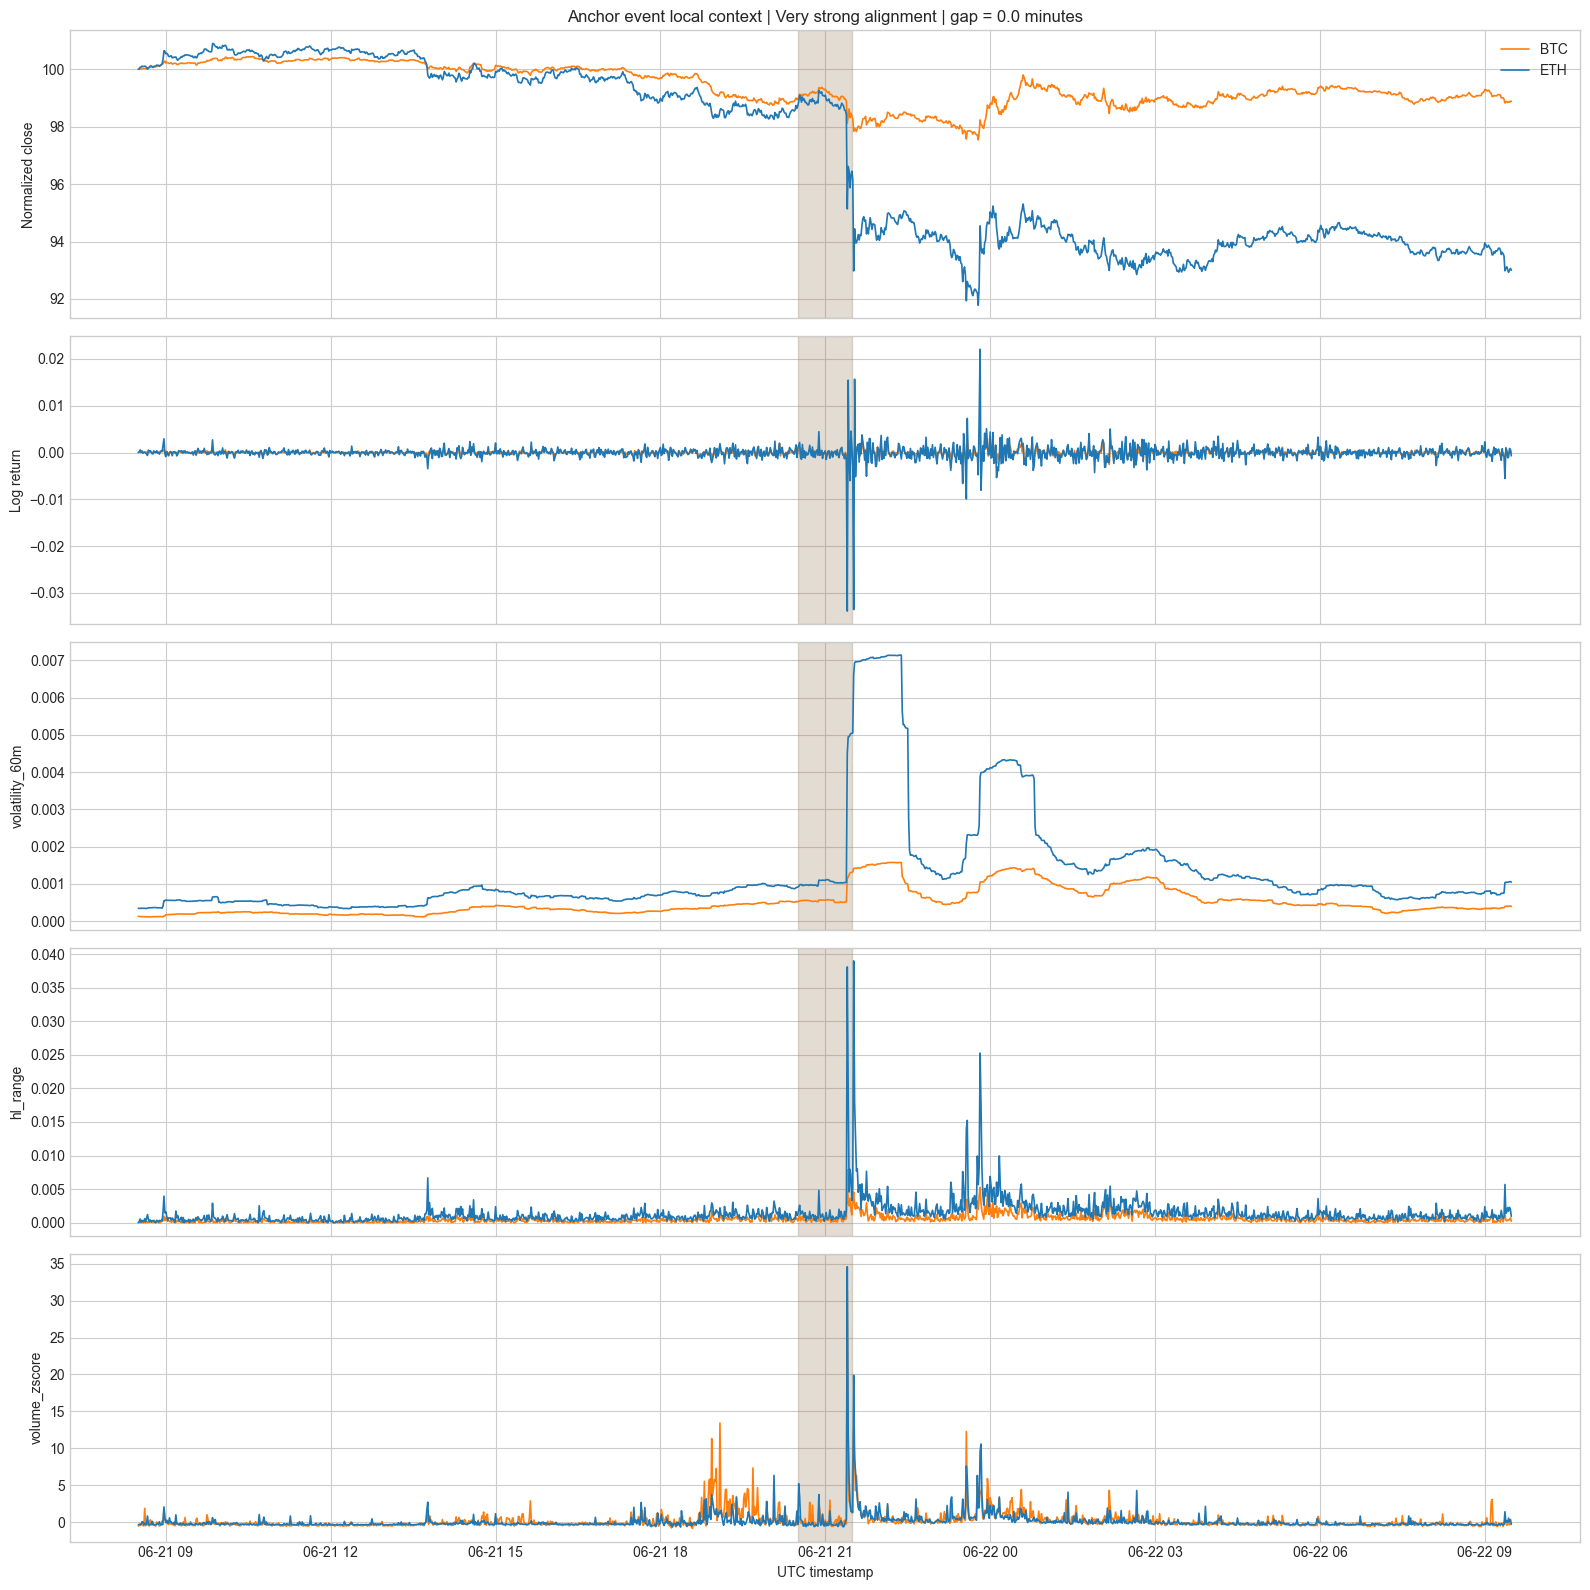

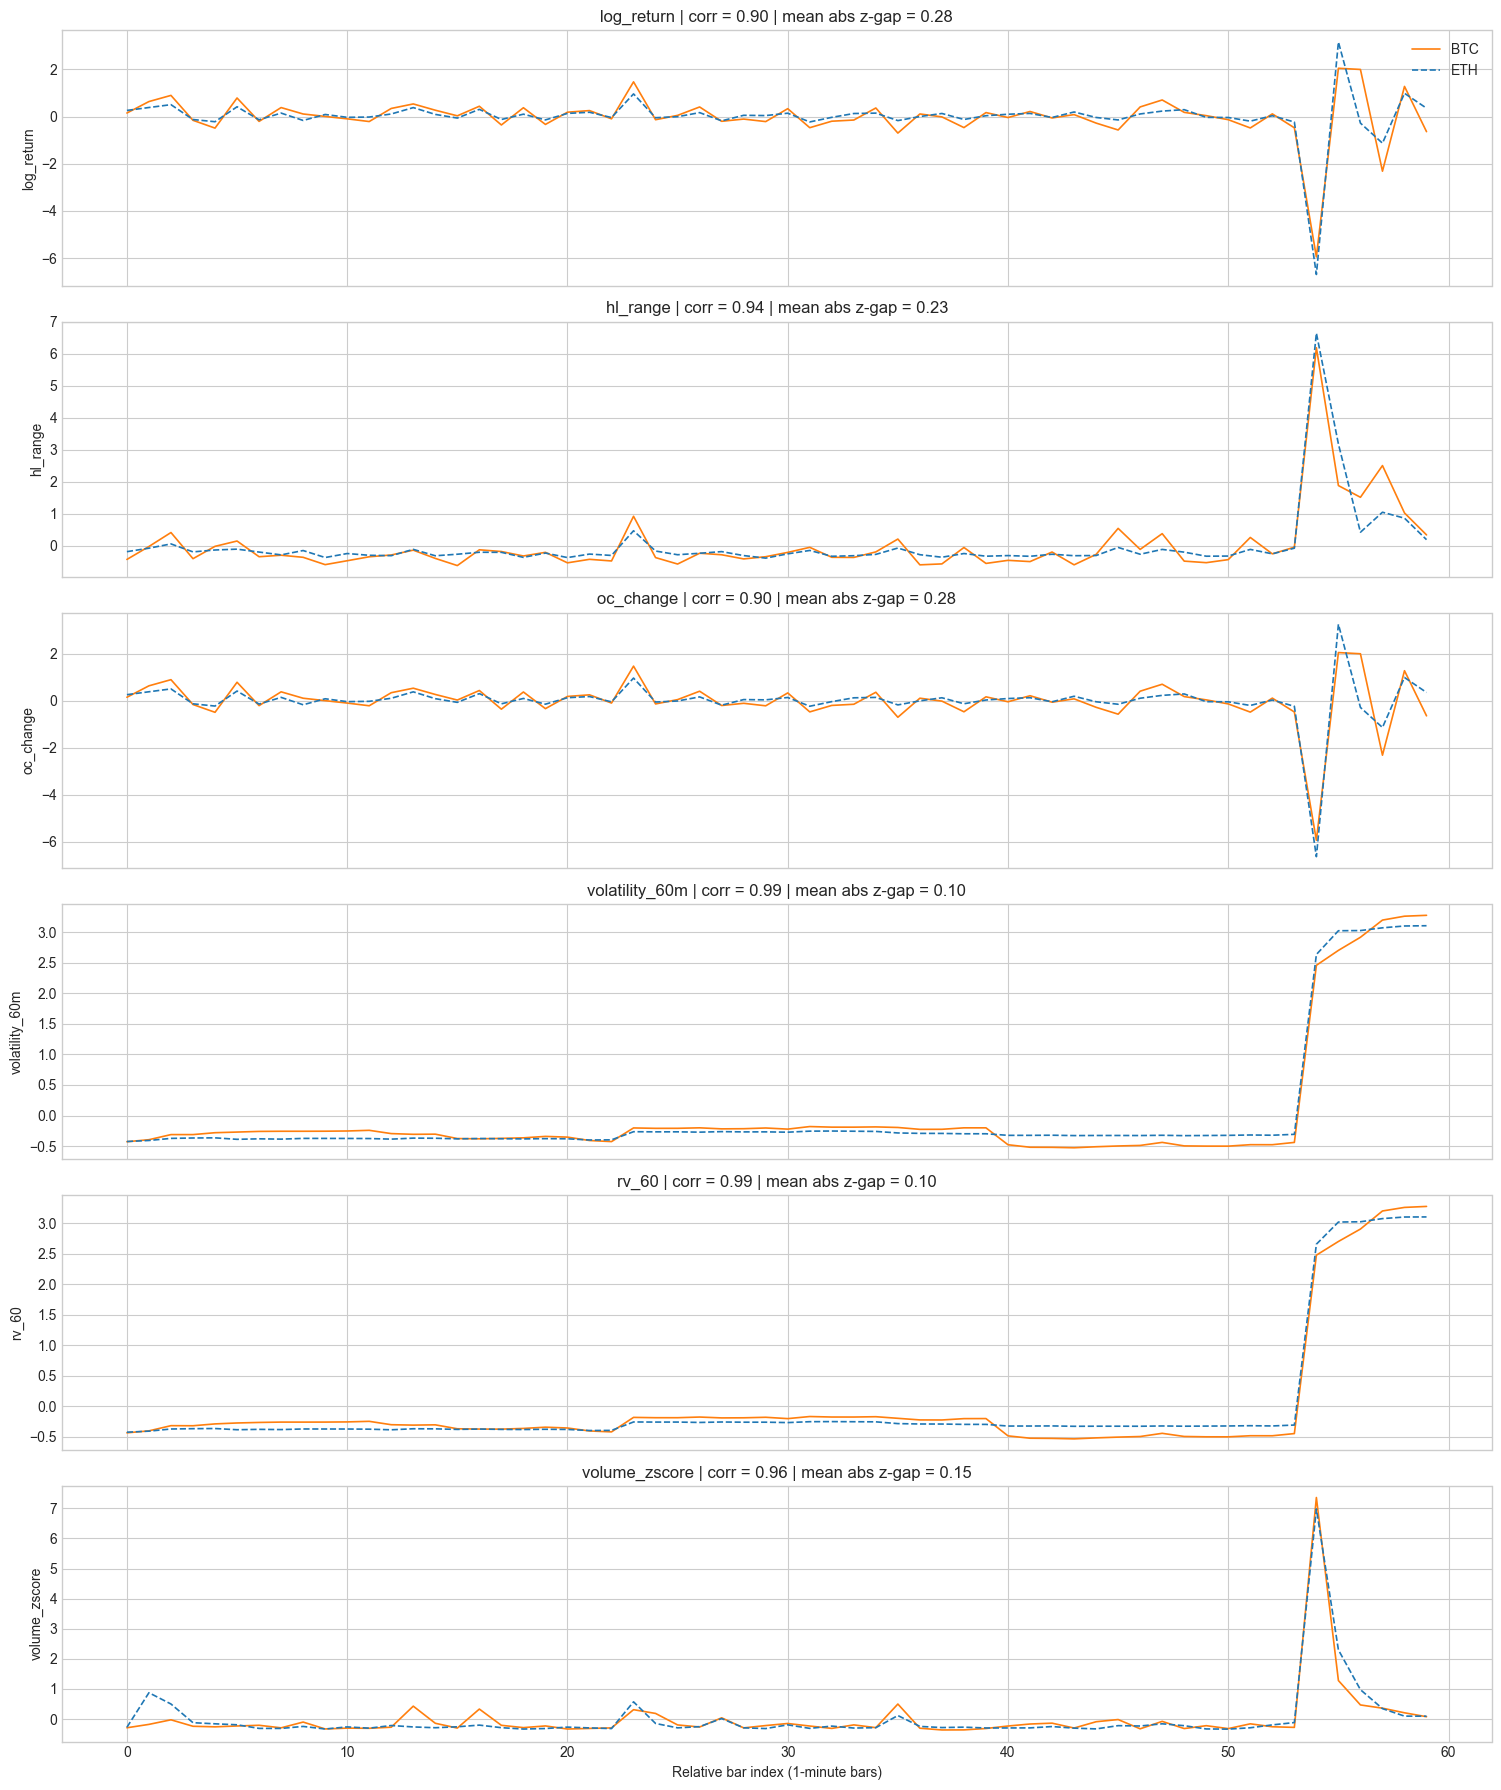

Dimension-level interpretability diagnostic


,feature,cross_asset_corr,mean_abs_z_gap,btc_window_std,eth_window_std
3,volatility_60m,0.993010,0.099900,0.000214,0.001171
4,rv_60,0.992741,0.102522,0.001648,0.009032
5,volume_zscore,0.964123,0.154297,4.141192,4.807521
1,hl_range,0.935962,0.225466,0.001150,0.005385
0,log_return,0.897609,0.283062,0.001301,0.005003
2,oc_change,0.896058,0.283635,0.001298,0.004961


In [9]:
def choose_first_feature(feature_pool: list[str], preferred_names: list[str]):
    for preferred_name in preferred_names:
        if preferred_name in feature_pool:
            return preferred_name
    return None


def normalize_to_100(series: pd.Series) -> np.ndarray:
    values = series.to_numpy(dtype=np.float64)
    if len(values) == 0:
        return values
    base_value = values[0]
    if not np.isfinite(base_value) or base_value == 0:
        return zscore_subsequence(values)
    return 100.0 * values / base_value


def locate_window_start(df_clean: pd.DataFrame, start_time: pd.Timestamp) -> int:
    matches = df_clean.index[df_clean["timestamp"] == pd.to_datetime(start_time, utc=True)]
    if len(matches) == 0:
        raise KeyError(f"Could not map start time {start_time} back to a clean dataframe index")
    return int(matches[0])


if anchor_event_row is None:
    print("Anchor-event validation skipped because no intersecting BTC/ETH motif windows were found.")
else:
    anchor_summary_cols = [
        "btc_motif_rank",
        "btc_window_type",
        "btc_start_time",
        "btc_end_time",
        "eth_motif_rank",
        "eth_window_type",
        "eth_start_time",
        "eth_end_time",
        "time_delta_minutes",
        "alignment_strength",
    ]
    print("Anchor event summary")
    display(pd.DataFrame([anchor_event_row[anchor_summary_cols]]))

    btc_anchor_index = locate_window_start(df_btc_clean, anchor_event_row["btc_start_time"])
    eth_anchor_index = locate_window_start(df_eth_clean, anchor_event_row["eth_start_time"])

    btc_anchor_window = df_btc_clean.iloc[btc_anchor_index: btc_anchor_index + WINDOW_BARS].copy()
    eth_anchor_window = df_eth_clean.iloc[eth_anchor_index: eth_anchor_index + WINDOW_BARS].copy()

    context_start = min(anchor_event_row["btc_start_time"], anchor_event_row["eth_start_time"]) - pd.Timedelta(hours=12)
    context_end = max(anchor_event_row["btc_end_time"], anchor_event_row["eth_end_time"]) + pd.Timedelta(hours=12)

    btc_context_df = df_btc_clean.loc[
        (df_btc_clean["timestamp"] >= context_start) & (df_btc_clean["timestamp"] <= context_end)
    ].copy()
    eth_context_df = df_eth_clean.loc[
        (df_eth_clean["timestamp"] >= context_start) & (df_eth_clean["timestamp"] <= context_end)
    ].copy()

    btc_context_df["close_norm"] = normalize_to_100(btc_context_df["close"])
    eth_context_df["close_norm"] = normalize_to_100(eth_context_df["close"])

    volatility_feature = choose_first_feature(selected_features, ["volatility_60m", "volatility_60", "rv_60"])
    volume_feature = choose_first_feature(selected_features, ["volume_zscore", "log_volume", "volume_change"])

    context_specs = [
        ("Normalized close", "close_norm"),
        ("Log return", "log_return"),
    ]
    if volatility_feature is not None:
        context_specs.append((volatility_feature, volatility_feature))
    if "hl_range" in selected_features:
        context_specs.append(("hl_range", "hl_range"))
    if volume_feature is not None:
        context_specs.append((volume_feature, volume_feature))

    fig, axes = plt.subplots(len(context_specs), 1, figsize=(16, 3.2 * len(context_specs)), sharex=True)
    if len(context_specs) == 1:
        axes = [axes]

    for axis, (label, column_name) in zip(axes, context_specs):
        axis.plot(btc_context_df["timestamp"], btc_context_df[column_name], label="BTC", color="tab:orange", linewidth=1.2)
        axis.plot(eth_context_df["timestamp"], eth_context_df[column_name], label="ETH", color="tab:blue", linewidth=1.2)
        axis.axvspan(anchor_event_row["btc_start_time"], anchor_event_row["btc_end_time"], color="tab:orange", alpha=0.16)
        axis.axvspan(anchor_event_row["eth_start_time"], anchor_event_row["eth_end_time"], color="tab:blue", alpha=0.12)
        axis.set_ylabel(label)

    axes[0].set_title(
        f"Anchor event local context | {anchor_event_row['alignment_strength']} alignment | "
        f"gap = {anchor_event_row['time_delta_minutes']:.1f} minutes"
    )
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("UTC timestamp")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(len(selected_features), 1, figsize=(15, 3.0 * len(selected_features)), sharex=True)
    if len(selected_features) == 1:
        axes = [axes]

    feature_diagnostics = []
    for axis, feature_name in zip(axes, selected_features):
        btc_values = zscore_subsequence(btc_anchor_window[feature_name].to_numpy())
        eth_values = zscore_subsequence(eth_anchor_window[feature_name].to_numpy())
        corr_value = safe_corr(btc_values, eth_values)
        mean_abs_gap = float(np.mean(np.abs(btc_values - eth_values)))

        feature_diagnostics.append(
            {
                "feature": feature_name,
                "cross_asset_corr": corr_value,
                "mean_abs_z_gap": mean_abs_gap,
                "btc_window_std": float(np.nanstd(btc_anchor_window[feature_name].to_numpy())),
                "eth_window_std": float(np.nanstd(eth_anchor_window[feature_name].to_numpy())),
            }
        )

        axis.plot(btc_values, label="BTC", color="tab:orange", linewidth=1.2)
        axis.plot(eth_values, label="ETH", color="tab:blue", linestyle="--", linewidth=1.2)
        axis.set_ylabel(feature_name)
        axis.set_title(f"{feature_name} | corr = {corr_value:.2f} | mean abs z-gap = {mean_abs_gap:.2f}")

    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel(f"Relative bar index ({BAR_MINUTES}-minute bars)")
    plt.tight_layout()
    plt.show()

    feature_diagnostic_df = pd.DataFrame(feature_diagnostics).sort_values(
        ["cross_asset_corr", "mean_abs_z_gap"],
        ascending=[False, True],
    )
    print("Dimension-level interpretability diagnostic")
    display(feature_diagnostic_df)


## 11. Interpretation Notes and Limitations

### Practical reading of the output
- Strong full-dimensional motifs indicate that the selected BTC/ETH feature panel contains a recurring joint state rather than a single-channel visual coincidence.
- The per-feature diagnostic table helps identify whether the anchor alignment is driven mostly by returns, volatility, range, or the selected volume channel.

### Methodological limits to keep explicit in the thesis
- **CPU cost**: multivariate `mstump` remains expensive on long 1-minute slices, which is why month-test mode is the default validation path.
- **Fixed window length**: a 60-minute window can miss recurring structures that stretch or compress in time.
- **Euclidean-style matching bias**: matrix profile similarity is still distance-based, so motifs that are semantically related but phase-shifted or nonlinearly warped may not rank highly.
- **Feature engineering dependency**: conclusions depend on the shared engineered feature panel; changing that panel changes the notion of similarity.
